# Population geometry of fixation type in four social-brain areas

*A chapter-style report. Sections: Introduction, Methods, Results, Discussion.*

---

### Abstract

Monkeys viewing a partner make three kinds of fixation: at a face during
interactive periods, at the same face during non-interactive periods, and at a
neutral object. We ask whether the neural populations of BLA, ACCg, dmPFC and
OFC treat these as three distinct states, and specifically whether the two face
conditions are more alike than either is to the object.

Using trial-averaged firing rates from 1,201 units, we find that all three
conditions occupy clearly separated regions of population state space in every
area, but that **the separation is mostly a static displacement** — roughly half
the population variance is a constant per-condition offset, and 55–75% of the
squared distance between any two conditions is positional rather than dynamic.

Measures of *subspace overlap* — how much of one condition's activity is captured
by another's principal directions — rank the two face conditions as most similar
in all four regions, but only by a small margin. The decisive difference appears
in a different quantity: **whether two conditions move through their own
neighbourhoods at the same moments**. By that measure the two face conditions are
strongly and significantly coupled in BLA, ACCg and OFC, while face-versus-object
pairs are indistinguishable from chance. dmPFC is the exception, showing weak
coupling for every pair.

We also find that the interactive-face state is markedly more compact and
lower-dimensional than the other two, and show that this survives correction for
the fivefold trial-count imbalance that would otherwise explain it.

---

### How to read this chapter

Methods are given twice: once in words, with the intuition for why the measure is
the right one, and once as the formula, so the analysis can be reproduced. Every
number in the text is computed in the cell above it, so the prose stays correct
if the analysis is rerun.

Regenerate with
`conda run -n gaze_processing python notebooks/population_thesis/_build_chapter.py`,
then execute. All reusable code lives in
`src/dal_monte_2022_analysis/ephys/analysis/fixation_population_pc_subspace.py`
and the matching plotting module. The exploratory notebooks that this chapter
draws on are in [`notebooks/population_pc_subspaces/`](../population_pc_subspaces).

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_population_pc_subspace as pcs
from dal_monte_2022_analysis.ephys.plotting import fixation_population_pc_subspace as viz
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
style.apply_thesis_plot_style(load_config(PLOTTING_CFG_PATH))
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

WINDOW_MS = (-500.0, 500.0)
VARIANCE_THRESHOLD = 0.95
N_NULL_SUBSPACES = 200
N_LABEL_SHUFFLES = 100
N_UNIT_BOOTSTRAPS = 200
N_SPLIT_HALVES = 50
RANDOM_SEED = 20260827
EXAMPLE_REGION = "bla"

FIGURE_DIR = pcs.resolve_output_dir(DATASET_CFG_PATH, scope="chapter")
FIGURE_MANIFEST: dict[str, Path] = {}
SHORT = {"face_interactive": "IF", "face_non_interactive": "NF", "object": "OB"}
PAIR_SHORT = {
    "face_interactive__vs__face_non_interactive": "IF/NF",
    "face_interactive__vs__object": "IF/OB",
    "face_non_interactive__vs__object": "NF/OB",
}
FIGURE_NUMBERS: dict[str, int] = {}


def figure(fig, stem: str, caption: str, *, dpi: int = 200) -> None:
    """Save as editable PDF plus PNG, display, and print a numbered caption."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    number = FIGURE_NUMBERS.setdefault(stem, len(FIGURE_NUMBERS) + 1)
    for extension in ("pdf", "png"):
        path = FIGURE_DIR / f"{stem}.{extension}"
        fig.savefig(path, dpi=dpi if extension == "png" else None, bbox_inches="tight", transparent=False)
        FIGURE_MANIFEST[f"{stem}.{extension}"] = path
    display(Image(filename=str(FIGURE_DIR / f"{stem}.png")))
    display(Markdown(f"**Figure {number}.** {caption}"))
    import matplotlib.pyplot as plt

    plt.close(fig)


def table(frame: pd.DataFrame, stem: str) -> pd.DataFrame:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / f"{stem}.csv"
    frame.to_csv(path, index=False)
    FIGURE_MANIFEST[f"{stem}.csv"] = path
    return frame


def unordered_pair(frame: pd.DataFrame) -> pd.DataFrame:
    labels = [
        pcs.pair_label(*sorted([a, b]))
        for a, b in zip(frame["pc_condition"], frame["eval_condition"])
    ]
    return frame.assign(pair_label=labels)


print("outputs:", FIGURE_DIR)

outputs: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_population_pc_subspace/chapter


---

## 1. Introduction

### 1.1 The question

In the dyadic task, one monkey's gaze lands on three kinds of target: the
partner's **face during an interactive period**, the **same face during a
non-interactive period**, and a neutral **object**. The three differ along two
axes at once — what is being looked at, and whether a social exchange is underway
— and the interesting comparison is not simply face versus object but whether the
*interactive context* changes how a face is represented.

At the level of single neurons this has already been characterised: a substantial
minority of cells in each area distinguish at least one pair of conditions. That
tells us the information is present, but not how it is organised. A population can
carry three distinguishable signals in many different ways, and those ways have
different implications:

- Three conditions could sit at **different levels along a shared axis** — a
  single "salience" dimension, with faces higher than objects.
- They could occupy **different subspaces** — the population using genuinely
  different combinations of neurons for each.
- They could share a subspace but **traverse it differently in time** — the same
  repertoire of states, visited in a different order or at different moments.

These are not distinguishable by counting selective neurons. They are questions
about geometry, and they need population-level measures.

### 1.2 What "subspace" means here, and why we care

Take a region with $N$ recorded neurons. At any instant the population is
described by $N$ numbers — one firing rate per neuron — so the population state
is a point in an $N$-dimensional space. Over the second surrounding a fixation,
that point traces a **trajectory**.

Real populations do not use all $N$ dimensions. Neurons are correlated, so the
trajectory is confined to a much lower-dimensional **subspace**: a flat sheet, or
a low-dimensional slab, sitting inside the full space. That subspace is a
meaningful object. It says which *patterns of coordinated activity* the population
actually produces, as opposed to which are anatomically possible.

The question of this chapter is whether the three fixation types use the **same**
subspace, and if so whether they move within it in the same way.

### 1.3 Why population geometry rather than more single-unit statistics

Two conditions can differ in every single neuron and still occupy the same
subspace — if each neuron's difference is a scaling of the same shared pattern.
Conversely two conditions can look similar neuron by neuron and still occupy
orthogonal subspaces, if the differences are small but coordinated. Neither case
is visible from selectivity counts. Geometry is the level at which the question
is well posed.

### 1.4 What this chapter finds

1. The three conditions occupy clearly separated population states in all four
   areas, and the separation is **mostly a static offset** rather than different
   dynamics.
2. **Subspace overlap** ranks the two face conditions as most similar in every
   region, but only narrowly.
3. **Time-locked co-movement** separates them decisively: the two face conditions
   move through their neighbourhoods in step; face and object do not. This is
   the chapter's main claim.
4. The **interactive-face state is compact and low-dimensional**, and this
   survives correction for the fivefold trial-count imbalance.
5. **dmPFC behaves differently** from the other three throughout.

---

## 2. Methods

### 2.1 Data

Trial-averaged peri-fixation firing rates, 10 ms bins, from
`fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl`. Per-trial rates
are Gaussian-smoothed at $\sigma = 20$ ms before averaging, then averaged; values
are in Hz.

The analysis window is $[-500, +500]$ ms around fixation onset, i.e. $T = 100$
bins. A unit enters only if it has an average for **all three** conditions, since
every comparison below requires the same neurons in every condition.

Interactive and non-interactive face come from the interactive-state–split
averages. Object comes from the **unsplit** average, pooling object fixations
across interactive state, because there are too few object fixations per state to
average reliably. This is a deliberate asymmetry and it matters for one thing
only — the object condition is not matched for interactive state — which §4.3
returns to.

In [2]:
populations = pcs.load_region_populations(DATASET_CFG_PATH, window_ms=WINDOW_MS)
inventory = table(pcs.build_unit_inventory(populations), "t01_inventory")
display(inventory[[
    "region", "n_units", "n_sessions", "n_time_bins",
    "fr_matrix_units_by_time", "concatenated_matrix_units_by_time",
    "median_trials_face_interactive", "median_trials_face_non_interactive", "median_trials_object",
]])
display(Markdown(
    f"**{int(inventory['n_units'].sum())} units total.** Note the trial columns: interactive-face "
    "averages rest on roughly five times as many fixations as the other two. §2.8 deals with that."
))

,region,n_units,n_sessions,n_time_bins,fr_matrix_units_by_time,concatenated_matrix_units_by_time,median_trials_face_interactive,median_trials_face_non_interactive,median_trials_object
0,accg,236,19,100,236 x 100,236 x 300,883.0,161.5,199.0
1,bla,537,35,100,537 x 100,537 x 300,846.0,164.0,168.0
2,dmpfc,187,17,100,187 x 100,187 x 300,883.0,167.0,168.0
3,ofc,241,14,100,241 x 100,241 x 300,768.0,170.0,144.0


**1201 units total.** Note the trial columns: interactive-face averages rest on roughly five times as many fixations as the other two. §2.8 deals with that.

### 2.2 From spike rates to a population trajectory

For each region and each condition, arrange the averages into a matrix with one
row per neuron and one column per time bin:

$$X_c \in \mathbb{R}^{N \times T}, \qquad c \in \{\text{IF}, \text{NF}, \text{OB}\}$$

Column $t$ of $X_c$ is the population state at time $t$ — the $N$ firing rates
read off together. Reading across the columns traces the trajectory.

To compare the three conditions they must be expressed in **one coordinate
system**. So the three matrices are laid side by side along time,

$$X = \begin{bmatrix} X_{\text{IF}} & X_{\text{NF}} & X_{\text{OB}}\end{bmatrix}
\in \mathbb{R}^{N \times 3T}$$

and a single set of axes is derived from the combined matrix. Deriving separate
axes per condition would give each trajectory its own coordinate system, and any
distance measured between them would be meaningless.

### 2.3 Principal component analysis, and which mean it removes

PCA here treats **time bins as observations and neurons as variables**. It asks:
across these $3T$ snapshots of the population, which weighted combinations of
neurons vary the most together?

Concretely, let $Y = X^{\top}$ (so each row is one time bin), subtract the mean
over all $3T$ rows, and take the singular value decomposition:

$$\mu = \tfrac{1}{3T}\textstyle\sum_s Y_{s\cdot}, \qquad
Y - \mathbf{1}\mu^{\top} = U\Sigma V^{\top}$$

The first $k$ columns of $V$ — call them $W = V_{:,1:k}^{\top}$, with
$WW^{\top} = I_k$ — are the principal components. **Each is a direction in neuron
space: a weighting over all $N$ neurons.** Projecting a condition onto them gives
its trajectory in PC coordinates,

$$Z_c = W\left(X_c - \mu\mathbf{1}^{\top}\right) \in \mathbb{R}^{k \times T}$$

and the reconstruction back to firing rates is
$\hat{X}_c = W^{\top}Z_c + \mu\mathbf{1}^{\top}$.

**Which mean is subtracted decides what the analysis can see.** Two choices recur:

| Fit on | Centred on | Keeps |
| --- | --- | --- |
| the concatenated matrix | the grand mean over all three conditions | each condition's offset from the others — this is what makes the trajectories appear as three separated clouds |
| a single condition | that condition's **own** average state | only that condition's variation about its own centre — the offset is gone before the axes are computed |

#### Which fit each measure uses

This distinction runs through the whole chapter, so it is worth having in one
place:

| Measure | Fitted on | Sees the offsets? |
| --- | --- | --- |
| 3D trajectories, component time courses (Figs 3–5) | **concatenated** | yes — that is what makes the three clouds separate |
| Centroid distance, offset/dynamics split (Figs 6, 9 left) | **concatenated** | yes, and reports the offset explicitly |
| Time-resolved separation (Fig 13) | **concatenated** | yes |
| **Deviation correlation** (Figs 6, 8, 9 right, 10 *y*-axis) | **concatenated**, then each condition's centroid subtracted *within* that basis | **no** — removed by step 3 of §2.8 |
| Cross-condition variance explained (Fig 7) | **per condition** | no |
| **Alignment index** (Fig 10 *x*-axis), principal angles | **per condition** | no |

The rule behind it: a measure that compares two *bases* can let each condition
have its own frame, because bases are compared to each other directly. A measure
that compares two *trajectories* cannot — the two must be expressed in one
coordinate system or the distance between them is meaningless. So all the
trajectory measures use the concatenated fit, and the deviation correlation
removes the offsets afterwards rather than by choosing a different fit.

Because a single-condition PCA centres on that condition's own average state,
every subspace comparison is *already blind to the offsets*. That is easy to get
wrong, so it is verified numerically rather than assumed.

### 2.4 Choosing how many dimensions to keep

Pictures use three components because a page is two-dimensional. Every number
uses more, because three components capture only about half the variance and any
comparison computed on them would describe the picture rather than the data.

The retained count is the smallest $k$ whose cumulative variance reaches 95% in
the region that needs the most:

$$k = \max_R\ \min\left\{k : \tfrac{\sum_{j\le k}\lambda_j}{\sum_j \lambda_j} \ge 0.95\right\}$$

Taking the maximum rather than the average guarantees no region is analysed in a
space too small for it.

### 2.5 Verification

Concatenating three conditions and slicing the projection back apart is exactly
the kind of step that fails silently: a block swap would mislabel every
trajectory while leaving every figure looking plausible. Two families of checks
were run and are reported in full in the exploratory notebook.

**Numerical identities** (7 per region, all passing): the basis is orthonormal,
the stored mean is the sample mean, slicing the concatenated projection by
condition equals re-projecting that condition on its own, full-rank
reconstruction is exact, the projection conserves total energy, and no block is
written back shifted in time.

**A label check**, which the identities cannot provide — a pipeline that swapped
two conditions *consistently* would pass all of them. Each condition's trajectory
is back-projected to firing rates and scored against **every** condition's true
rates; the best match must be the diagonal.

In [3]:
fits = {region: pcs.fit_all_scopes(population) for region, population in populations.items()}
dimensionality = table(pcs.build_dimensionality_table(fits), "t02_dimensionality")
K, per_region_components = pcs.resolve_shared_n_components(fits, threshold=VARIANCE_THRESHOLD)

checks = pd.concat(
    [pcs.verify_pca_identities(p, fits[r]["concatenated"]) for r, p in populations.items()],
    ignore_index=True,
)
confusion = pd.concat(
    [
        pcs.condition_identity_confusion(p, fits[r]["concatenated"], n_components=K)
        for r, p in populations.items()
    ],
    ignore_index=True,
)
diagonal = confusion[confusion["reconstructed_from"] == confusion["compared_against"]]
offset_invariance = pcs.verify_subspace_offset_invariance(populations, n_components=K)

display(Markdown(
    f"- Numerical identities: **{int(checks['passed'].sum())} / {len(checks)} pass**.\n"
    f"- Condition identity recovered in **{int(diagonal['identity_recovered'].sum())} / {len(diagonal)}** "
    "region x condition cases; every reconstruction matches its own condition best.\n"
    f"- Subspace measures are unchanged by explicit centroid removal in "
    f"**{int(offset_invariance['offset_invariant'].sum())} / {len(offset_invariance)}** cases "
    f"(max difference {offset_invariance['alignment_difference'].max():.1e}), confirming they never "
    "saw the offsets."
))

- Numerical identities: **28 / 28 pass**.
- Condition identity recovered in **12 / 12** region x condition cases; every reconstruction matches its own condition best.
- Subspace measures are unchanged by explicit centroid removal in **12 / 12** cases (max difference 5.6e-16), confirming they never saw the offsets.

### 2.6 Splitting the response into three parts — without tensor language

This is the step that makes the rest interpretable, so it is worth doing slowly,
one neuron at a time. Forget the population for a moment.

**What goes in:** raw firing rates in Hz, one neuron at a time. **No PCA is
involved in this step at all**, and no choice of $k$ affects it. (Because PCA
with an orthonormal basis is a rotation, doing the split in full-rank PC space
would give identical numbers — but working on the rates directly avoids the
question entirely.)

**One neuron has three curves**, one per condition, each 100 points long. They
are firing rates, so they are non-negative — this one sits around 50 Hz.

First set aside the neuron's **baseline**: its overall mean across all three
conditions and all time bins, a single number. Everything below describes
*departures from that baseline*, so the three parts are centred on zero even
though the rates themselves are not. Adding the baseline back to the three parts
reproduces the original curves exactly.

Now ask three questions in turn.

1. **Does the neuron have a response that happens for every condition?**
   Average the three curves together, point by point. Whatever structure survives
   that average is common to all three — a response to *fixating*, whatever is
   being fixated. Call it the **shared time course**.

2. **Do the three curves sit at different heights?**
   Take each curve's own average level — a single number per condition. If those
   three numbers differ, the neuron fires at different rates for different
   fixation types, steadily across the whole window. Call that the **condition
   offset**. *This is the centroid: the condition's average position.*

3. **Is anything left after removing both?**
   Subtract the shared time course, and subtract each curve's own level. What
   remains is a bump that one condition has and the others do not — a genuinely
   **condition-specific wiggle**, i.e. an interaction between condition and time.

Baseline plus those three parts reproduces the original curves exactly. That is
not a coincidence: each part is constructed by averaging over a different thing,
and averaging over one index makes a term uncorrelated with a term that varies
only along that index. Because they are uncorrelated, their **squared sizes add
up**:

$$\underbrace{\sum(\text{observed} - \text{baseline})^2}_{\text{total}}
= \underbrace{\sum(\text{shared time course})^2}_{\text{part 1}}
+ \underbrace{\sum(\text{condition offset})^2}_{\text{part 2}}
+ \underbrace{\sum(\text{what is left})^2}_{\text{part 3}}$$

So each part can be quoted as a **percentage of the neuron's total variation**,
and the three percentages sum to 100%. Do this for every neuron, add the squares
across neurons, and the same three percentages describe the whole region.

(For readers who want the index notation: with $r_{ctn}$ the rate for condition
$c$, bin $t$, neuron $n$, and a dot denoting an average over that index, the
three parts are $\bar r_{\cdot tn} - \bar r_{\cdot\cdot n}$,
$\bar r_{c\cdot n} - \bar r_{\cdot\cdot n}$, and the remainder. It is the standard
two-way ANOVA split, and the additivity is its usual orthogonality property.)

**Why we want this.** "The conditions are separated" is ambiguous between *they
sit in different places* and *they do different things over time*. Part 2 and part
3 answer those separately, and they turn out to have very different sizes.

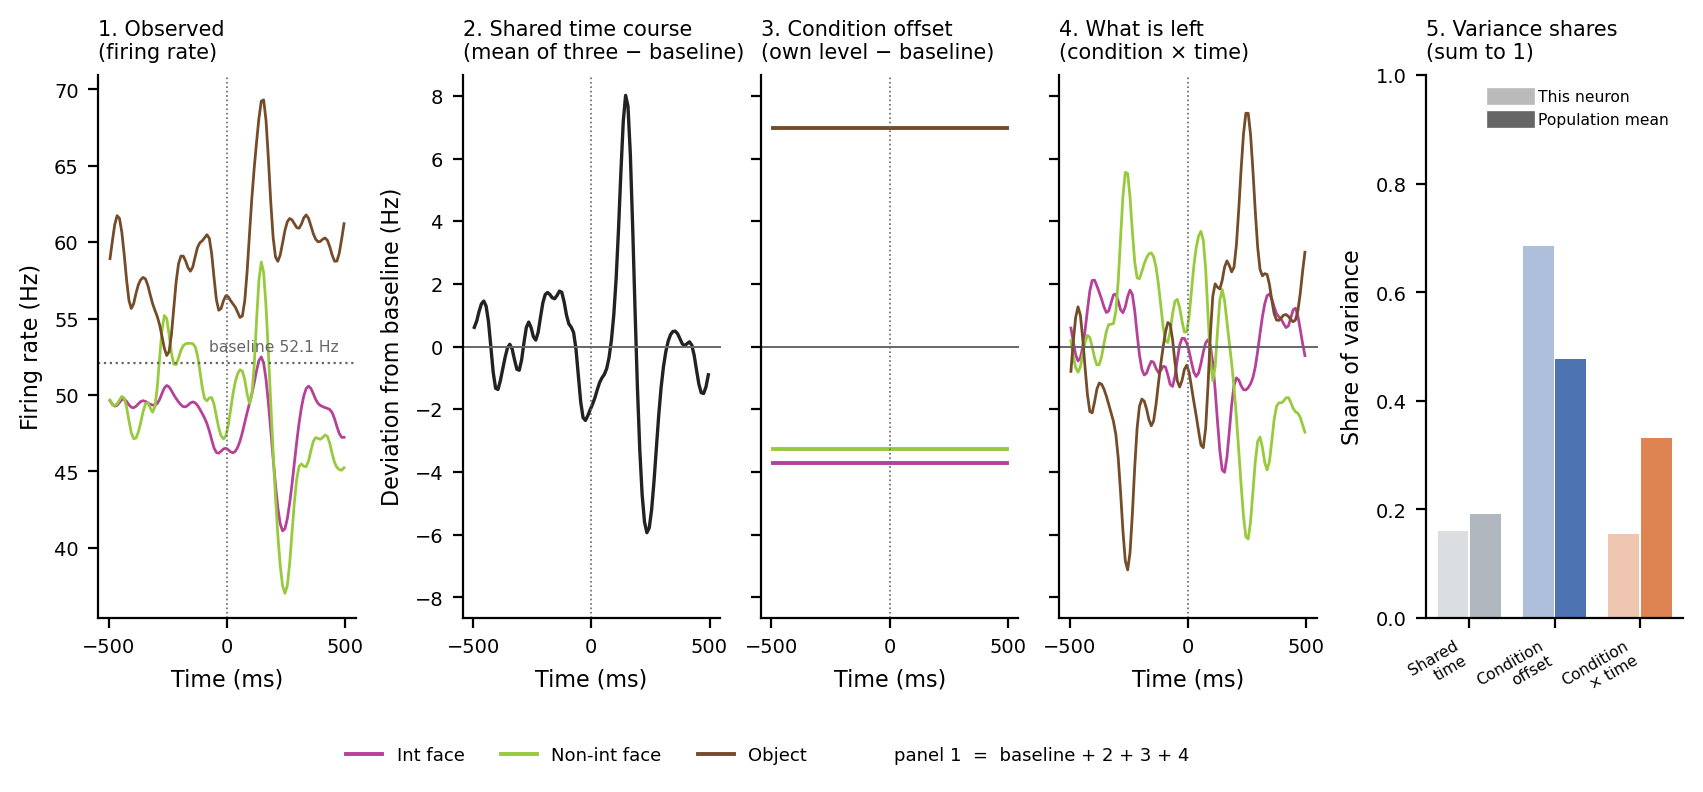

**Figure 1.** **The three-part split, worked through on one neuron** (`01092019|unit_uuid__2587`, BLA). Raw firing rates; no PCA is involved. *1*: the three observed condition curves, which are non-negative and sit around 52 Hz; the dotted line is the neuron's baseline, its overall mean across conditions and time. *2–4*: the three parts the response splits into, each plotted as a **deviation from that baseline** — which is why they are centred on zero while panel 1 is not, and why they share a y-axis so their relative sizes can be compared. *2*: the point-by-point average of the three curves, the response common to all conditions. *3*: each curve's own level, the condition offset (the three necessarily sum to zero). *4*: what is left once both are removed. Baseline + 2 + 3 + 4 reproduces panel 1 exactly. *5*: the share of variance each part carries, for this neuron and averaged over all regions. The offset dominates for this neuron, as it does for the population.

Additivity check for the neuron above: max |baseline + part 2 + part 3 + part 4 − observed| = **1.4e-14 Hz**, and the three condition offsets sum to 5.3e-15. The split is exact, not approximate.

In [4]:
example_population = populations[EXAMPLE_REGION]
example_index = pcs.select_decomposition_example_unit(example_population)
example = pcs.single_unit_decomposition(example_population, example_index)

decomposition = table(
    pd.concat([pcs.condition_variance_decomposition(p) for p in populations.values()], ignore_index=True),
    "t03_variance_decomposition",
)
shares = decomposition.pivot(index="region", columns="component", values="fraction_of_total")

reconstruction = (
    example["baseline"]
    + example["shared_time_course"][None, :]
    + example["condition_offsets"][:, None]
    + example["residual"]
)
figure(
    viz.plot_decomposition_schematic(example, shares),
    "fig01_decomposition_schematic",
    f"**The three-part split, worked through on one neuron** (`{example['unit_key']}`, "
    f"{style.region_label(EXAMPLE_REGION)}). Raw firing rates; no PCA is involved. "
    "*1*: the three observed condition curves, which are non-negative and sit around "
    f"{example['baseline']:.0f} Hz; the dotted line is the neuron's baseline, its overall mean across "
    "conditions and time. *2–4*: the three parts the response splits into, each plotted as a "
    "**deviation from that baseline** — which is why they are centred on zero while panel 1 is not, "
    "and why they share a y-axis so their relative sizes can be compared. *2*: the point-by-point "
    "average of the three curves, the response common to all conditions. *3*: each curve's own level, "
    "the condition offset (the three necessarily sum to zero). *4*: what is left once both are "
    "removed. Baseline + 2 + 3 + 4 reproduces panel 1 exactly. *5*: the share of variance each part "
    "carries, for this neuron and averaged over all regions. The offset dominates for this neuron, "
    "as it does for the population.",
)
display(Markdown(
    "Additivity check for the neuron above: "
    f"max |baseline + part 2 + part 3 + part 4 − observed| = "
    f"**{np.abs(reconstruction - example['curves']).max():.1e} Hz**, and the three condition offsets "
    f"sum to {example['condition_offsets'].sum():.1e}. The split is exact, not approximate."
))

### 2.7 Comparing subspaces: do the conditions use the same directions?

Each condition, considered on its own, varies about its own centre in some
preferred set of directions. Two questions follow, and they need different tools.

#### Cross-condition variance explained — the natural first measure

Take condition $a$'s top-$k$ directions. Project condition $b$'s activity onto
them. **What fraction of $b$'s variation survives?** If the two conditions use the
same directions, almost all of it does; if the directions are unrelated, little
does.

Formally, with $C_c$ the covariance across neurons of condition $c$'s activity
about its own mean, and $V_a$ the top-$k$ eigenvectors of $C_a$:

$$\text{fraction}(a \to b) = \frac{\operatorname{tr}\left(V_a^{\top}C_b V_a\right)}{\operatorname{tr}(C_b)}$$

This is **asymmetric**, and informatively so: a condition whose variance is spread
broadly makes a more general basis than one whose variance is concentrated.

#### Alignment index — putting the number on a scale

The raw fraction has no reference. How much *could* any $k$-dimensional subspace
capture of $b$? At most $b$'s own top-$k$ eigenvalues. Dividing by that ceiling
gives the **alignment index**:

$$A(a \to b) = \frac{\operatorname{tr}\left(V_a^{\top}C_b V_a\right)}{\sum_{j\le k}\lambda_j(C_b)} \in [0,1]$$

$A = 1$ means $a$'s directions are **as good for $b$ as $b$'s own best choice**;
$A = 0$ means they are orthogonal to everything $b$ does.

**A trap worth flagging.** A randomly chosen $k$-dimensional subspace of an
$N$-dimensional space already captures a fraction $k/N$ of anything, purely by
chance. Our regions have very different neuron counts, so at $k = 42$ the chance
floor ranges from $42/537 = 0.08$ in BLA to $42/187 = 0.22$ in dmPFC. **Raw
alignment indices are therefore not comparable across regions.** We report

$$A^{\dagger} = \frac{A - k/N}{1 - k/N}$$

which puts chance at zero. The analytic floor is checked against simulated random
subspaces below.

#### Principal angles — the scale-free view

The alignment index weights directions by how much variance lies along them.
Principal angles do not: they ask only whether the *directions* coincide. For
orthonormal bases $V_a, V_b$, the angles $\theta_1 \le \cdots \le \theta_k$ satisfy
$\cos\theta_j = s_j(V_a^{\top}V_b)$, the singular values of the overlap matrix.
$\theta = 0$ is a shared direction, $\theta = 90°$ is an orthogonal one, and
$\sum_j\cos^2\theta_j$ counts the effective number of shared dimensions.

### 2.8 Time-locked co-movement: the measure this chapter turns on

Everything so far asks where the conditions sit, or which directions they *can*
move along. Neither asks whether they move along them **at the same time**. That
turns out to be the question that separates faces from objects, so it is worth
being precise about what is computed and why.

#### The intuition

Picture two dancers in a room.

- **Subspace overlap** asks: do they use the same set of moves? Two dancers with
  the same repertoire score high, whether or not they are ever doing the same
  thing at once.
- **Co-movement** asks: are they dancing *in sync*? When one leans left, does the
  other lean left at that moment?

These are different, and a pair can score high on one and zero on the other. Two
conditions that share a repertoire but visit it at unrelated times have a common
*capacity* but no common *process*. Two that move together are being driven by
something shared and time-locked to the fixation.

#### The computation, step by step

1. Take each condition's trajectory in the shared PC space, $Z_c(t)$.
2. Compute its **centroid**, $m_c = \frac{1}{T}\sum_t Z_c(t)$ — its average
   position over the window. This is the offset from §2.6, now as a vector.
3. Subtract it: $d_c(t) = Z_c(t) - m_c$. Each condition is now a wiggle about its
   own centre, with the static difference removed. **Nothing below can be driven
   by the offsets.**
4. At each time bin, take the **dot product** $d_a(t)^{\top}d_b(t)$. This is
   positive when the two conditions are displaced in the same direction at that
   moment, negative when opposite, near zero when unrelated.
5. Average over time and normalise by the two trajectories' typical sizes:

$$\rho_{ab} = \frac{\left\langle d_a(t)^{\top} d_b(t)\right\rangle_t}
{\sqrt{\left\langle\|d_a\|^2\right\rangle_t\,\left\langle\|d_b\|^2\right\rangle_t}} \in [-1,1]$$

It is an ordinary correlation coefficient, except that the things being
correlated are *vectors* moving in $k$-dimensional space rather than scalars.
$\rho = 1$ means the two conditions trace the same excursion at the same time;
$\rho = 0$ means they move independently.

#### Why it needs its own null

Both trajectories are smooth — they were built from 20 ms-smoothed averages — and
**two smooth curves correlate substantially by accident.** Comparing $\rho$ to
zero would be far too permissive.

The right null keeps everything about each trajectory except their alignment in
time. We **circularly shift** one condition's wiggle relative to the other and
recompute. Each trajectory keeps its own shape, its own smoothness and its own
size; only the claim "these two things happen at the same moment" is destroyed.
If the observed $\rho$ is just a smoothness artefact, shifted versions will match
it. If it reflects real synchrony, they will not.

All 81 admissible shifts are used (shifts under 10 bins are excluded because a
smoothed trajectory still overlaps itself there), so the test is exact rather
than sampled. With 81 shifts the smallest attainable $p$ is $1/82 = 0.012$; the
$z$-score against the shift distribution is the graded measure.

### 2.9 Controlling for the trial-count imbalance

Interactive-face fixations outnumber the other two roughly **five to one**. A
mean built from more trials is less noisy, and a **less noisy average looks like a
population that moves less**. So any comparison of how much the conditions move is
partly a comparison of trial counts unless it is corrected.

Each stored average carries a standard error $s_c(t,n)$. Treating estimation noise
as independent across neurons, its energy in the PC basis is

$$\nu_c(t) = \sum_{j\le k}\sum_n V_{nj}^2\, s_c(t,n)^2$$

which is subtracted from the measured excursion, offset and covariance.

One subtlety decides whether this works. The 20 ms smoothing makes the noise
**autocorrelated**, $\rho_{\text{noise}}(\ell) = \exp(-\ell^2/4\sigma^2)$ with
$\sigma = 2$ bins. Treating it as independent overstates the noise in a
bin-to-bin difference by more than tenfold and drives every corrected speed to
zero regardless of the data. With the kernel-aware model, moment-to-moment speed
turns out to be **barely resolvable** above the noise floor, so this chapter makes
no claims about speed. Excursion and dimensionality integrate over the whole
window and survive correction comfortably.

For $\rho_{ab}$ the correction applies to the denominator only: the numerator is
already unbiased because noise is independent *across conditions*. Note the
direction of the bias — the uncorrected $\rho$ is pulled **toward zero**, hardest
for the conditions with fewest trials. Failing to correct would make a real shared
dynamic look like an absence of one.

---

## 3. Results

### 3.1 The three conditions occupy separated population states

We start with the picture, because the picture is unambiguous and everything that
follows is an attempt to say precisely what it shows.

**k = 42 components** reach 95% of the variance in every region (ACCg 40, BLA 42, dmPFC 33, OFC 38); BLA is binding. All quantitative results below use all of them; the figures below use three.

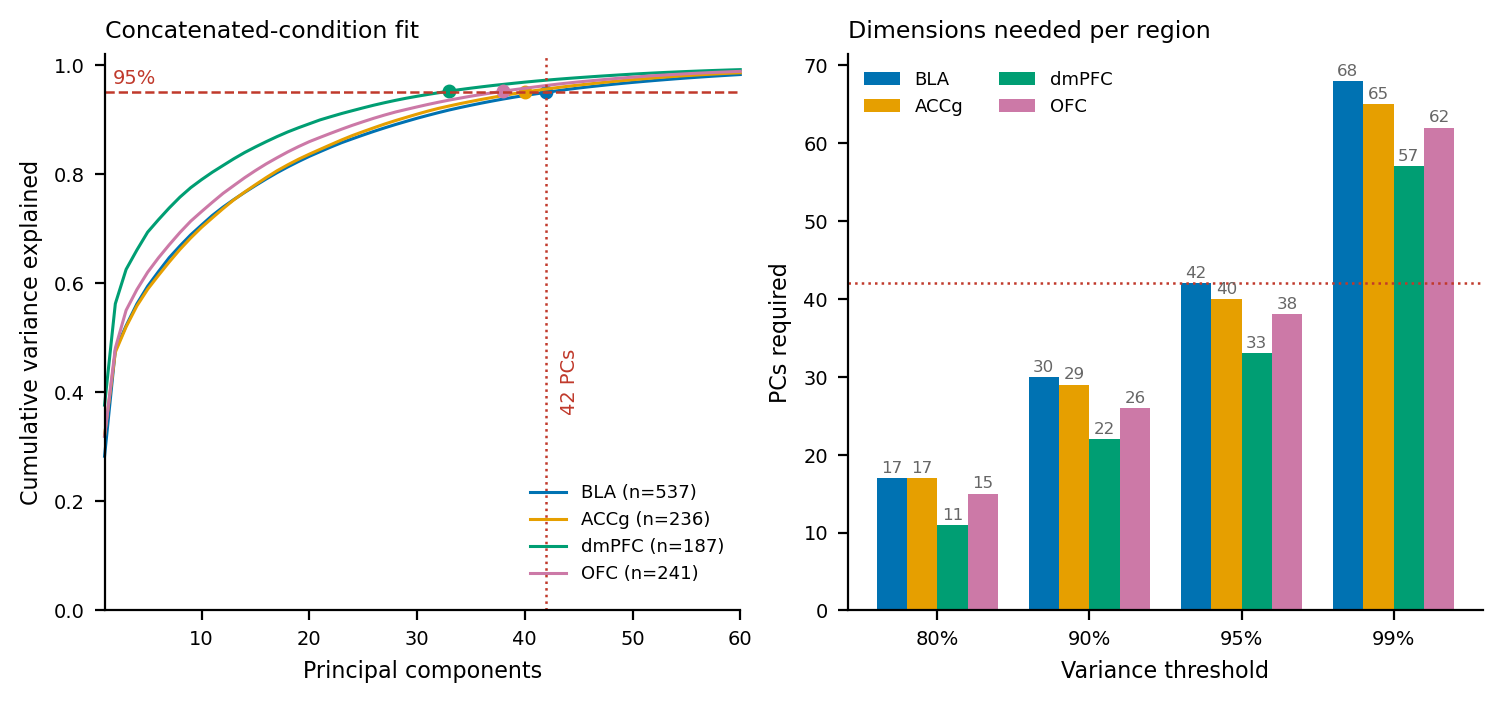

**Figure 2.** **How many dimensions the populations need.** *Left*: cumulative variance explained by the concatenated fit; dots mark where each region crosses 95%. *Right*: components required at four thresholds. The dotted line is the shared retained dimension, set by the most demanding region. A handful of components carry most of the variance, but a long tail is needed to reach 95% — which is why the pictures use three components and the statistics use all of them.

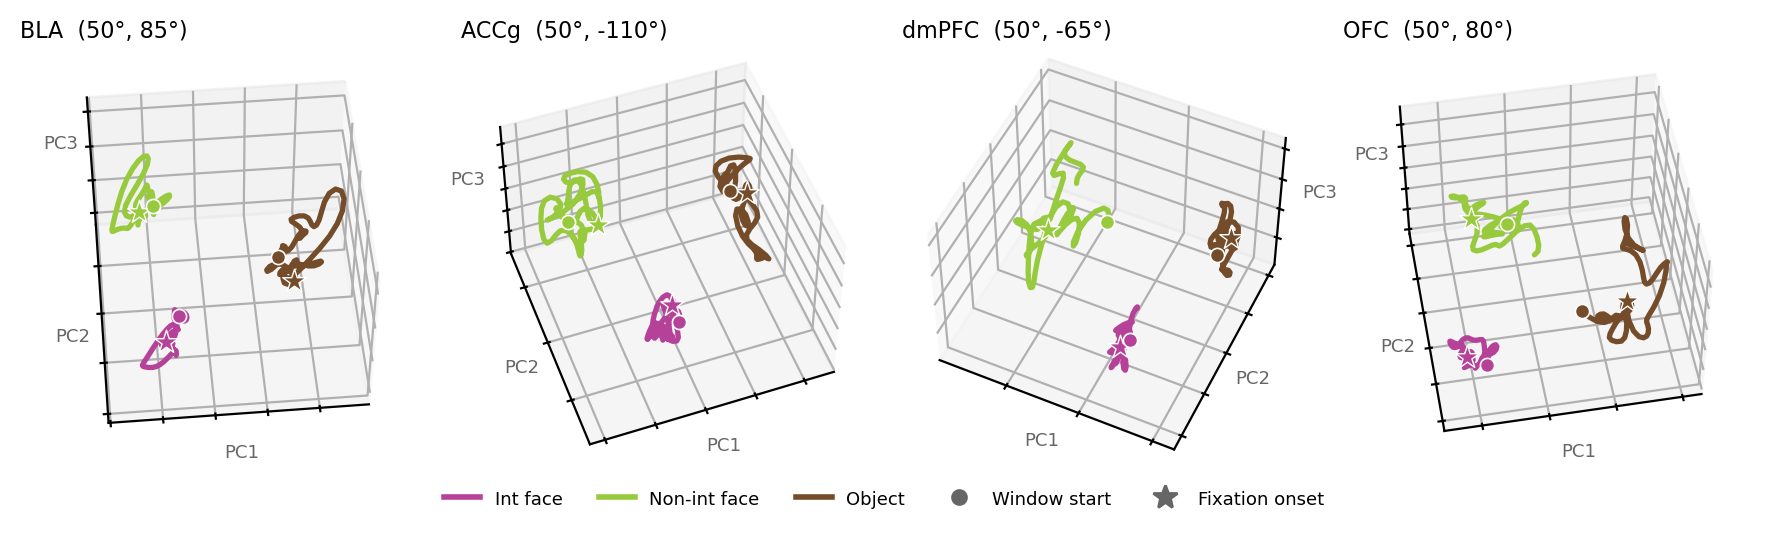

**Figure 3.** **Population trajectories in the top three components.** One panel per region, all three conditions in the same coordinate system (the concatenated fit), so the distances shown are real. Circle marks the start of the window, star marks fixation onset. Viewing angles are chosen per region by maximising the product of between-condition separation and within-trajectory unfolding — a single fixed camera collapses two trajectories in at least one area. The three conditions form three compact, well-separated clouds in every region.

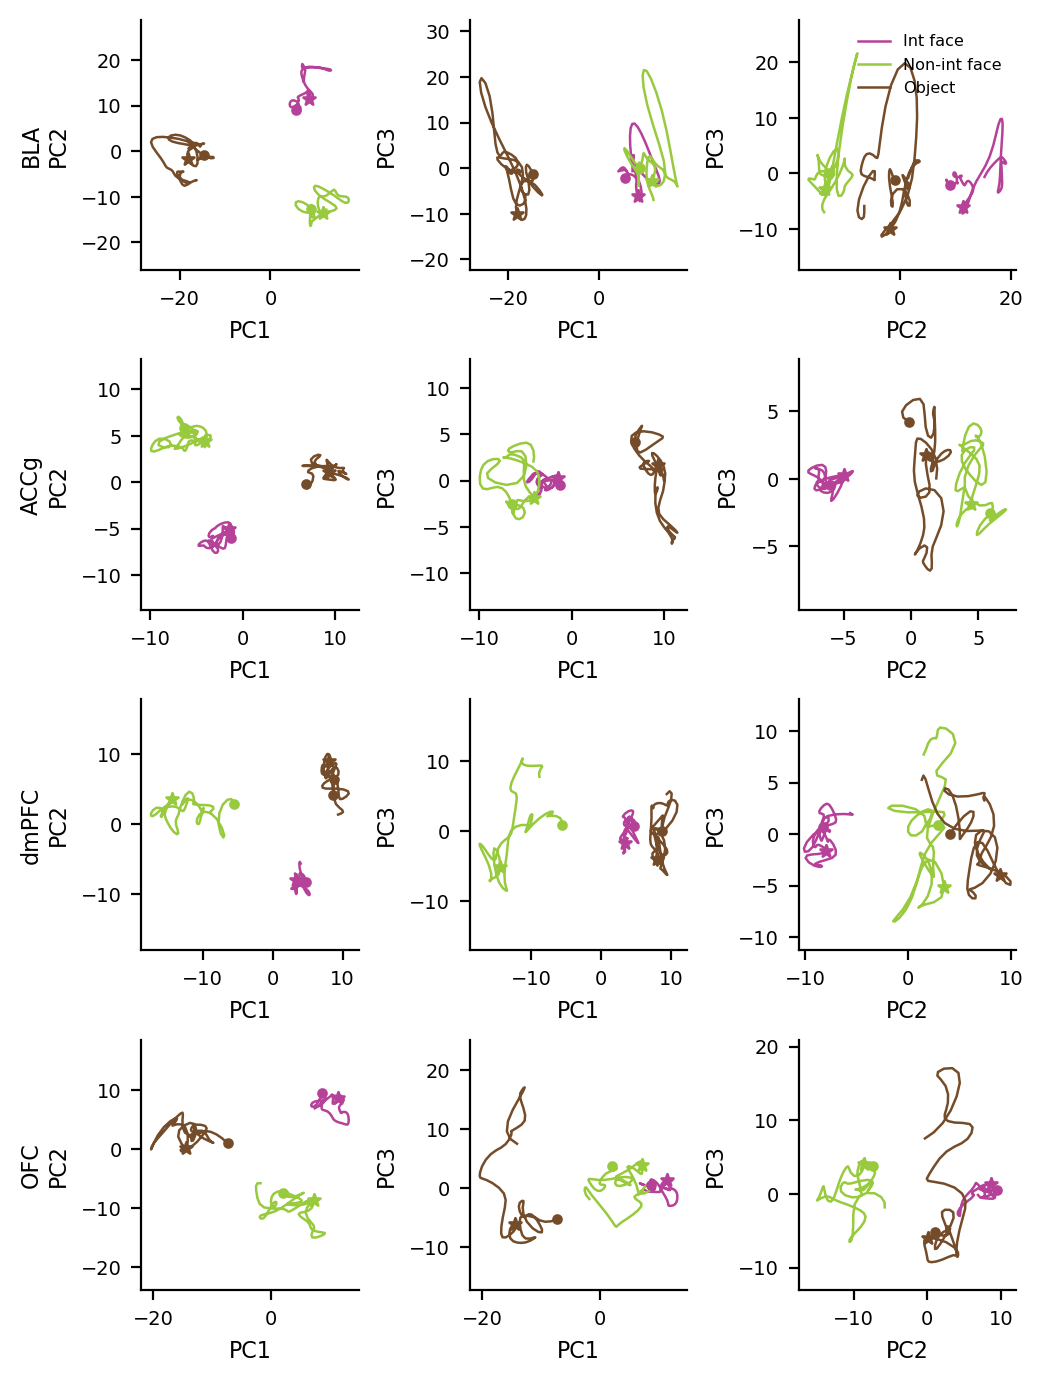

**Figure 4.** **The same trajectories in fixed component planes.** A camera can always be chosen to flatter 3D data; these projections have no free parameters, so they are the honest check on Figure 3. The separation survives: in every region and nearly every plane the three conditions are disjoint, with object typically furthest from both face conditions.

In [5]:
display(Markdown(
    f"**k = {K} components** reach {VARIANCE_THRESHOLD:.0%} of the variance in every region "
    "(" + ", ".join(f"{style.region_label(r)} {c}" for r, c in sorted(per_region_components.items()))
    + f"); {style.region_label(max(per_region_components, key=per_region_components.get))} is binding. "
    "All quantitative results below use all of them; the figures below use three."
))
figure(
    viz.plot_cumulative_variance(fits, threshold=VARIANCE_THRESHOLD, shared_n_components=K),
    "fig02_dimensionality",
    "**How many dimensions the populations need.** *Left*: cumulative variance explained by the "
    "concatenated fit; dots mark where each region crosses 95%. *Right*: components required at four "
    "thresholds. The dotted line is the shared retained dimension, set by the most demanding region. "
    "A handful of components carry most of the variance, but a long tail is needed to reach 95% — "
    "which is why the pictures use three components and the statistics use all of them.",
)

figure_3d, views = viz.plot_pc_trajectories_3d(fits)
figure(
    figure_3d,
    "fig03_trajectories_3d",
    "**Population trajectories in the top three components.** One panel per region, all three "
    "conditions in the same coordinate system (the concatenated fit), so the distances shown are real. "
    "Circle marks the start of the window, star marks fixation onset. Viewing angles are chosen per "
    "region by maximising the product of between-condition separation and within-trajectory "
    "unfolding — a single fixed camera collapses two trajectories in at least one area. "
    "The three conditions form three compact, well-separated clouds in every region.",
)
figure(
    viz.plot_pc_plane_projections(fits),
    "fig04_pc_planes",
    "**The same trajectories in fixed component planes.** A camera can always be chosen to flatter "
    "3D data; these projections have no free parameters, so they are the honest check on Figure 3. "
    "The separation survives: in every region and nearly every plane the three conditions are "
    "disjoint, with object typically furthest from both face conditions.",
)

### 3.2 But the separation is mostly a static offset

Figure 3 shows three separated clouds — but a cloud is a position, not a
trajectory. Two facts show that the separation is largely positional.

**First**, the component time courses are close to flat and displaced from one
another, rather than differently shaped.

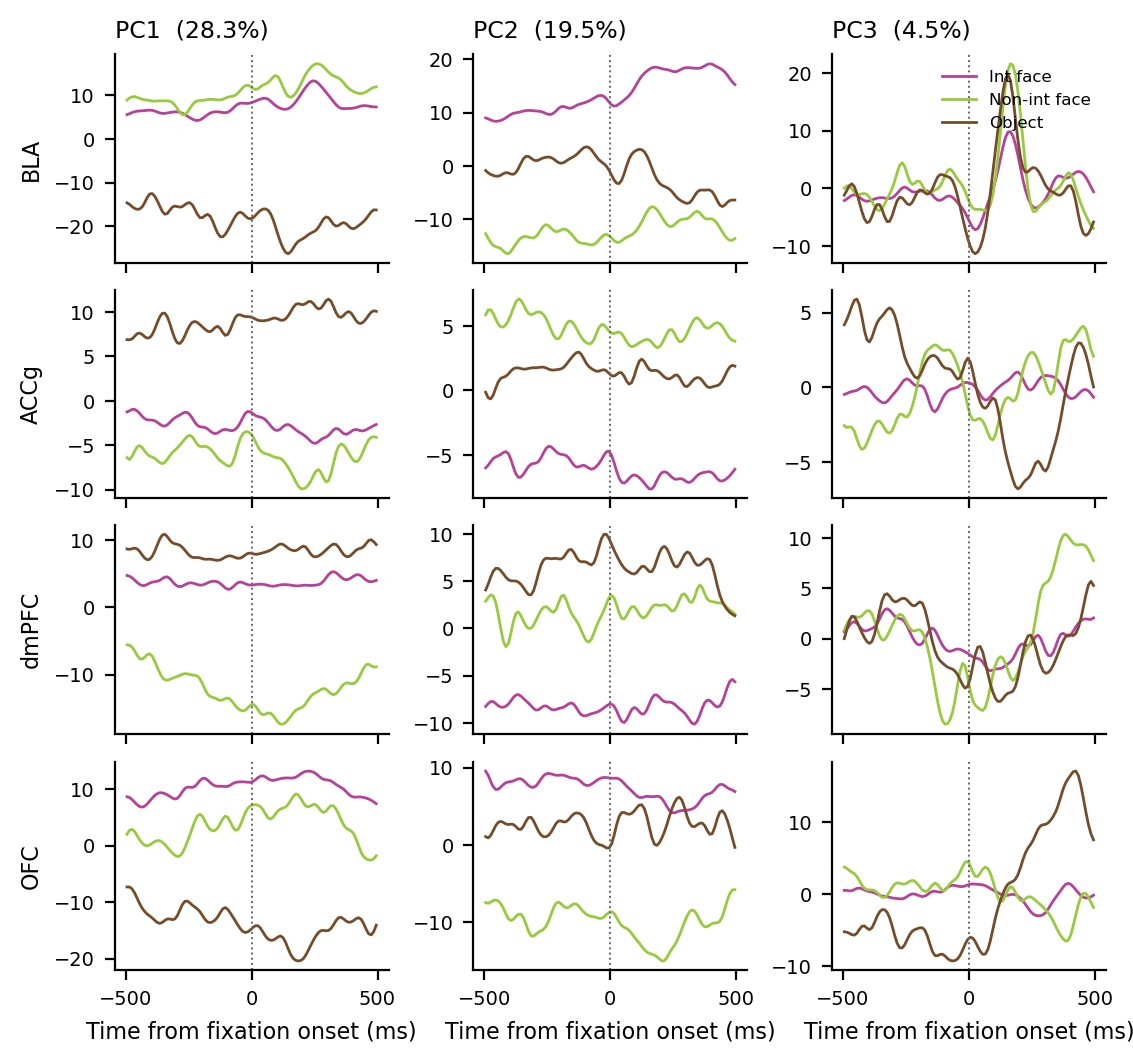

**Figure 5.** **Component scores against time.** Rows are regions, columns the first three components, with the percentage of variance each carries. The dominant feature is that the three conditions sit at different, roughly constant levels; the fixation-locked modulation on top is comparatively small. This is the separation of Figure 3, seen as a function of time.

**Share of population variance carried by each part of the response**

component,Shared time course,Condition offset,Condition x time
region,,,
accg,0.184,0.458,0.357
bla,0.212,0.455,0.333
dmpfc,0.177,0.539,0.284
ofc,0.191,0.455,0.354


Sums per region: `accg` 1.0000, `bla` 1.0000, `dmpfc` 1.0000, `ofc` 1.0000 — the three parts account for the variance exactly, as §2.6 requires.

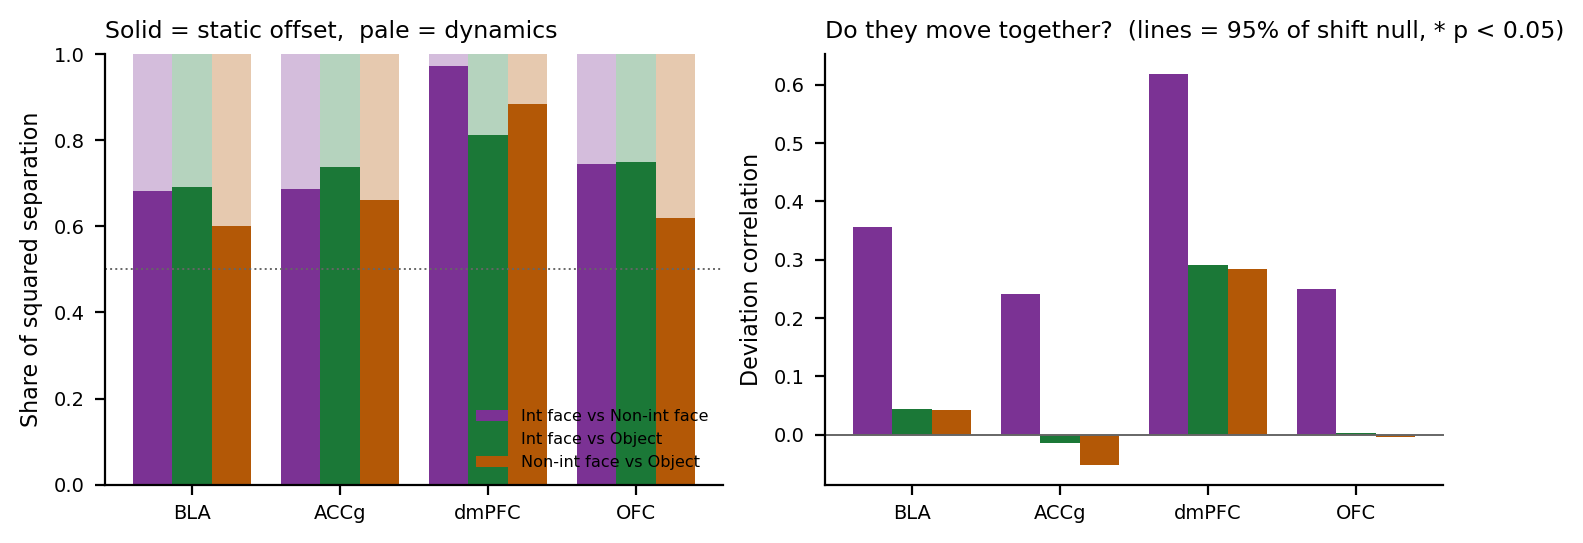

**Figure 6.** **Two independent facts about each pair of conditions.** *Left*: take the distance between two conditions at each time bin, square it, average over time. That number splits exactly in two — how far apart their centroids are (solid), and how differently they wiggle about those centroids (pale). The split is exact because the wiggles average to zero, so the cross term vanishes. Across every region and pair, the solid part is the larger one: the conditions are separated mainly by sitting in different places. *Right*: a different question entirely — having removed the centroids, do the two conditions wiggle *in the same direction at the same moment*? That is the deviation correlation, previewed here and tested in §3.4. Note it is not predicted by the left panel: a pair can be far apart and still move together, or close together and move independently.

In [6]:
figure(
    viz.plot_pc_timecourses(fits),
    "fig05_pc_timecourses",
    "**Component scores against time.** Rows are regions, columns the first three components, with "
    "the percentage of variance each carries. The dominant feature is that the three conditions sit "
    "at different, roughly constant levels; the fixation-locked modulation on top is comparatively "
    "small. This is the separation of Figure 3, seen as a function of time.",
)

display(Markdown("**Share of population variance carried by each part of the response**"))
display(shares[[
    "condition_independent_time", "condition_main_effect", "condition_by_time_interaction",
]].rename(columns={
    "condition_independent_time": "Shared time course",
    "condition_main_effect": "Condition offset",
    "condition_by_time_interaction": "Condition x time",
}).round(3))
display(Markdown(
    "Sums per region: "
    + ", ".join(
        f"`{r}` {shares.loc[r, ['condition_independent_time','condition_main_effect','condition_by_time_interaction']].sum():.4f}"
        for r in shares.index
    )
    + " — the three parts account for the variance exactly, as §2.6 requires."
))

offset_dynamics = table(
    pcs.build_offset_vs_dynamics_table(populations, fits, n_components=K), "t04_offset_vs_dynamics"
)
figure(
    viz.plot_offset_vs_dynamics(offset_dynamics, shift_test=None),
    "fig06_offset_vs_dynamics",
    "**Two independent facts about each pair of conditions.** *Left*: take the distance between "
    "two conditions at each time bin, square it, average over time. That number splits exactly in "
    "two — how far apart their centroids are (solid), and how differently they wiggle about those "
    "centroids (pale). The split is exact because the wiggles average to zero, so the cross term "
    "vanishes. Across every region and pair, the solid part is the larger one: the conditions are "
    "separated mainly by sitting in different places. *Right*: a different question entirely — "
    "having removed the centroids, do the two conditions wiggle *in the same direction at the same "
    "moment*? That is the deviation correlation, previewed here and tested in §3.4. Note it is not "
    "predicted by the left panel: a pair can be far apart and still move together, or close "
    "together and move independently.",
)

### 3.3 Subspace overlap ranks faces together — but only just

If the two face conditions were representationally closer to each other than to
object, the most natural place to see it is subspace overlap: the faces should
share directions that neither shares with object.

They do — consistently, in every region — but the margin is small.

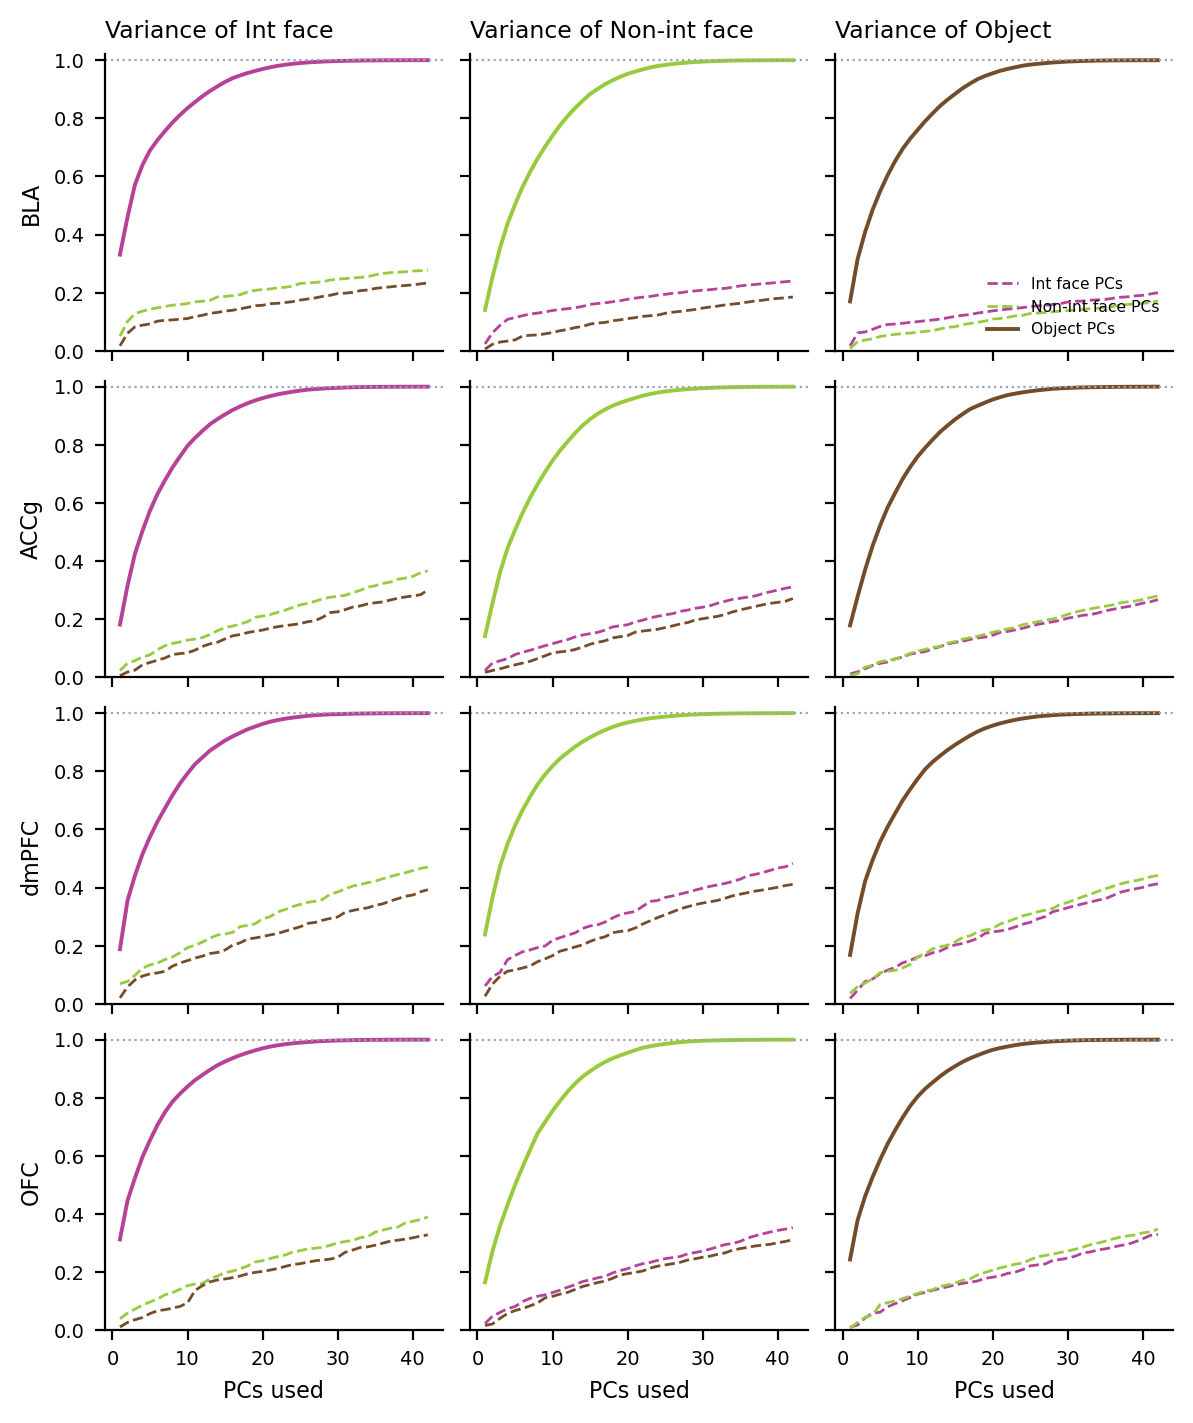

**Figure 7.** **Variance of each condition captured by each condition's components.** Rows are regions, columns the condition whose variance is being explained. The solid curve is that condition explained by its own components (the ceiling, by construction). Dashed curves are the other two. Cross-condition curves plateau far below the within-condition curve — the conditions genuinely occupy different subspaces — and the two face conditions explain each other slightly better than object explains either.

**Analytic chance floor k/N against the simulated random-subspace null**

,n_units,alignment_null_mean,alignment_floor_analytic
region,,,
accg,236.0,0.1780,0.1780
bla,537.0,0.0783,0.0782
dmpfc,187.0,0.2253,0.2246
ofc,241.0,0.1749,0.1743


**Subspace overlap by pair.** `alignment_above_floor` is the cross-region-comparable column.

,region,pair,alignment_index,chance_floor,alignment_above_floor,mean_principal_angle,shared_dimensions
0,accg,IF/NF,0.339,0.178,0.196,61.207,11.596
1,accg,IF/OB,0.284,0.178,0.129,63.384,10.266
2,accg,NF/OB,0.276,0.178,0.119,63.103,10.413
3,bla,IF/NF,0.259,0.078,0.196,69.858,6.488
4,bla,IF/OB,0.217,0.078,0.151,70.819,5.994
5,bla,NF/OB,0.179,0.078,0.109,70.940,5.878
6,dmpfc,IF/NF,0.477,0.225,0.326,55.497,15.188
7,dmpfc,IF/OB,0.403,0.225,0.230,57.904,13.730
8,dmpfc,NF/OB,0.427,0.225,0.261,57.189,14.102
9,ofc,IF/NF,0.372,0.174,0.239,59.328,12.782


**IF/NF is the most-aligned pair in 4 of 4 regions**, but it leads the next-best pair by only 0.057 on average (range 0.046-0.067) on a scale where 0 is chance and 1 is a perfect match. The ordering is consistent; the effect is small.

In [7]:
subspace_table = table(
    pcs.build_region_subspace_summary(
        populations, fits, n_components=K, n_null_subspaces=N_NULL_SUBSPACES, seed=RANDOM_SEED
    ),
    "t05_subspace_metrics",
)
variance_curves = table(
    pd.concat(
        [pcs.cross_condition_variance_curve(p, fits[r], max_components=K) for r, p in populations.items()],
        ignore_index=True,
    ),
    "t06_cross_condition_variance_curves",
)
ceiling = table(
    pd.concat(
        [pcs.within_condition_alignment_ceiling(p, n_components=K) for p in populations.values()],
        ignore_index=True,
    ),
    "t07_alignment_ceiling",
)
off = subspace_table.loc[~subspace_table["is_within_condition"]]

figure(
    viz.plot_cross_condition_variance_curves(variance_curves, ceiling=ceiling),
    "fig07_cross_condition_variance",
    "**Variance of each condition captured by each condition's components.** Rows are regions, "
    "columns the condition whose variance is being explained. The solid curve is that condition "
    "explained by its own components (the ceiling, by construction). Dashed curves are the other two. "
    "Cross-condition curves plateau far below the within-condition curve — the conditions genuinely "
    "occupy different subspaces — and the two face conditions explain each other slightly better "
    "than object explains either.",
)

display(Markdown("**Analytic chance floor k/N against the simulated random-subspace null**"))
display(off.groupby("region")[["n_units", "alignment_null_mean", "alignment_floor_analytic"]].mean().round(4))

pair_summary = table(
    unordered_pair(off).groupby(["region", "pair_label"]).agg(
        alignment_index=("alignment_index", "mean"),
        chance_floor=("alignment_floor_analytic", "mean"),
        alignment_above_floor=("alignment_above_floor", "mean"),
        mean_principal_angle=("angle_mean_principal_angle", "mean"),
        shared_dimensions=("angle_mean_cos2", lambda values: float(np.mean(values)) * K),
    ).reset_index(),
    "t08_pairwise_subspace_summary",
)
pair_summary["pair"] = pair_summary["pair_label"].map(PAIR_SHORT)
display(Markdown("**Subspace overlap by pair.** `alignment_above_floor` is the cross-region-comparable column."))
display(pair_summary[[
    "region", "pair", "alignment_index", "chance_floor", "alignment_above_floor",
    "mean_principal_angle", "shared_dimensions",
]].round(3))

winners = (
    pair_summary.loc[pair_summary.groupby("region")["alignment_above_floor"].idxmax()]
    .set_index("region")["pair"]
)
margins = []
for region in sorted(populations):
    sub = pair_summary[pair_summary["region"] == region].set_index("pair")["alignment_above_floor"]
    margins.append(float(sub["IF/NF"] - sub.drop("IF/NF").max()))
display(Markdown(
    f"**IF/NF is the most-aligned pair in {int((winners == 'IF/NF').sum())} of {len(winners)} regions**, "
    f"but it leads the next-best pair by only {np.mean(margins):.3f} on average "
    f"(range {min(margins):.3f}-{max(margins):.3f}) on a scale where 0 is chance and 1 is a perfect "
    "match. The ordering is consistent; the effect is small."
))

### 3.4 Time-locked co-movement separates faces from objects decisively

Subspace overlap says the conditions *can* move along similar directions. It says
nothing about whether they do so at the same moments. That second question gives a
much sharper answer.

Figure 8 shows the measure being computed, side by side for a pair that co-moves
and a pair that does not.

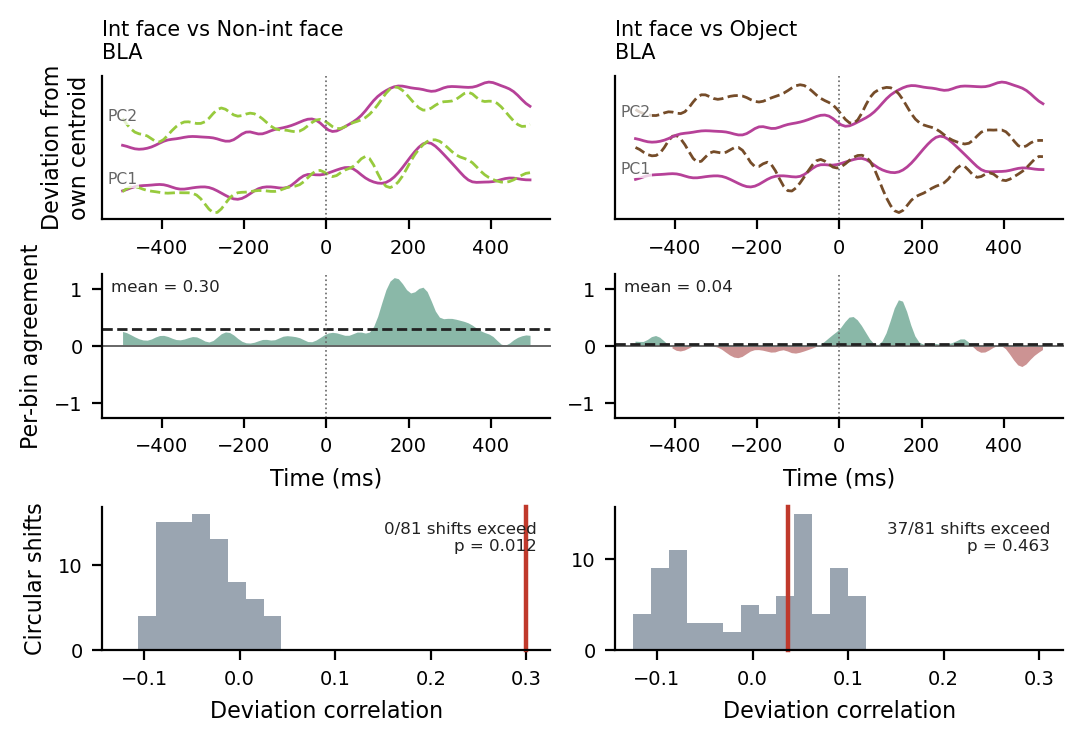

**Figure 8.** **What the deviation correlation measures** (BLA; left column a face-face pair, right a face-object pair). *Top*: each condition's trajectory after removing its own centroid, along the first two components — the question 'do they wiggle together?' is answerable by eye before any number is computed. *Middle*: the per-bin dot product, whose time average is the correlation; green is agreement, red disagreement, dashed line the mean. *Bottom*: the observed value (red) against all 81 circular time shifts. The face pair rises clear of every shift; the face-object pair sits inside the null distribution. Axes are shared across columns so the two are directly comparable.

**Time-locked co-movement, all regions and pairs**

,region,pair,observed_deviation_correlation,shift_null_mean,shift_null_sd,z_against_shift_null,p_value
0,bla,IF/NF,0.300,-0.040,0.034,10.061,0.012
1,bla,IF/OB,0.037,0.003,0.074,0.451,0.463
2,bla,NF/OB,0.035,0.002,0.030,1.080,0.122
3,accg,IF/NF,0.130,-0.024,0.032,4.747,0.012
4,accg,IF/OB,-0.009,-0.000,0.027,-0.309,0.561
5,accg,NF/OB,-0.033,0.007,0.023,-1.708,0.915
6,dmpfc,IF/NF,0.126,-0.027,0.076,2.008,0.061
7,dmpfc,IF/OB,0.132,-0.023,0.062,2.514,0.012
8,dmpfc,NF/OB,0.064,-0.009,0.041,1.742,0.024
9,ofc,IF/NF,0.142,-0.029,0.056,3.044,0.012


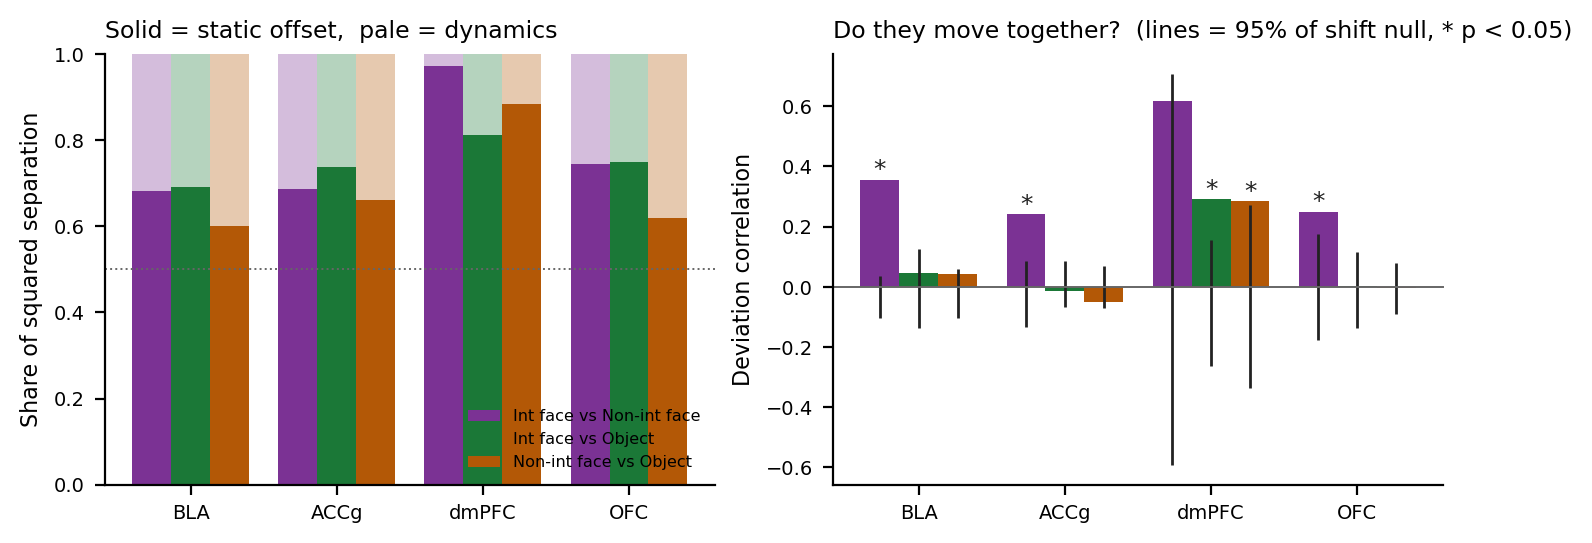

**Figure 9.** **Figure 6, now with the co-movement tested.** *Left*: unchanged — the static/moving split of the separation. *Right*: the same deviation-correlation bars as Figure 6, with each pair's circular-shift null drawn as its 2.5th-97.5th percentile range (black) and asterisks marking p < 0.05. The null band is what turns a bare correlation into a claim: it is where the value would sit if the two conditions had these exact trajectories but no shared timing. Only the face-face pair clears it in BLA, ACCg and OFC; dmPFC shows the opposite pattern.

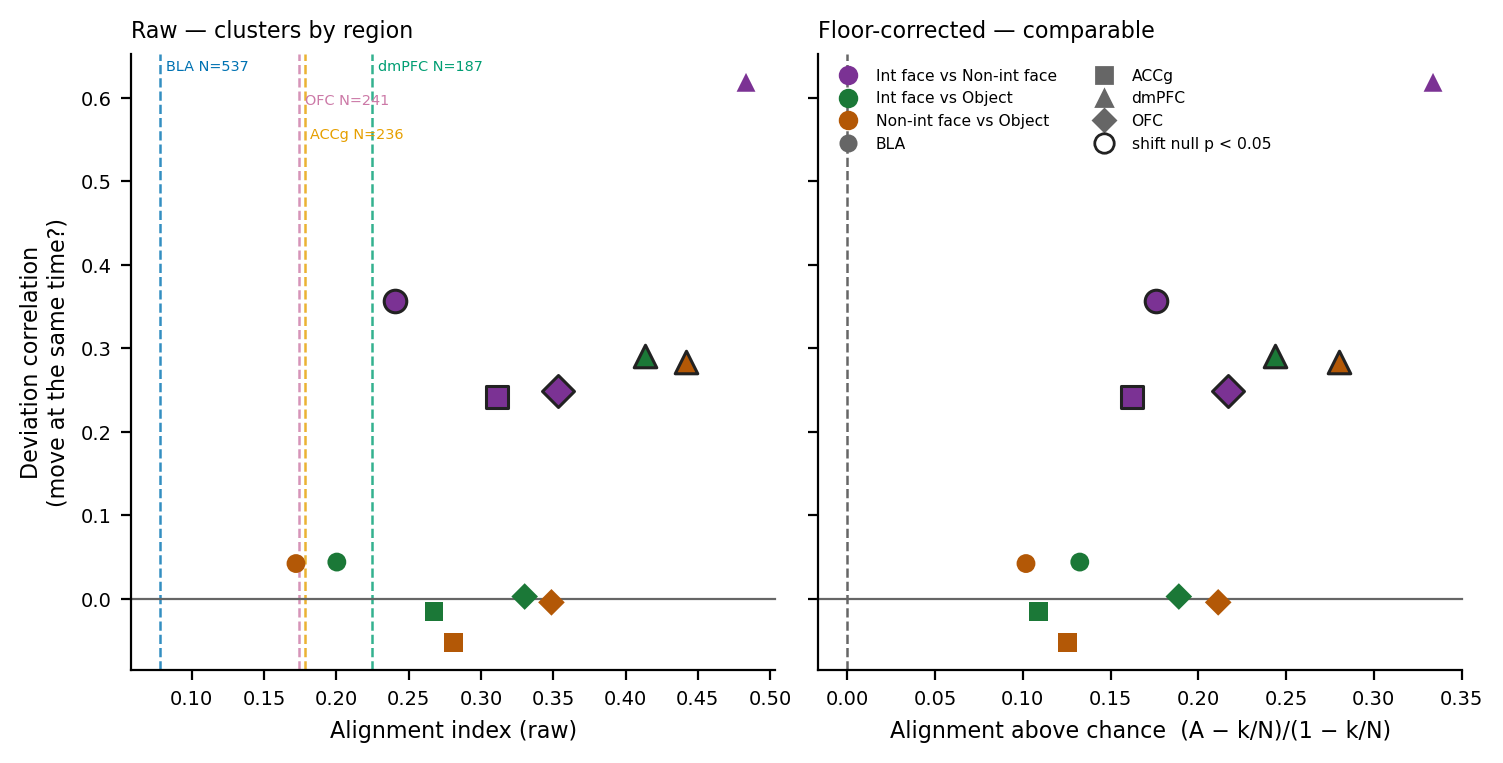

**Figure 10.** **The two questions plotted against each other.** Vertical axis in both panels: the deviation correlation — do the two conditions move at the same time? Horizontal axis: the alignment index — do they vary along the same directions at all? Colour is the condition pair, marker shape the region, ringed markers exceed the shift null.

*Left, raw alignment*: the points cluster by region, but that is mostly an artefact. A random 42-dimensional subspace already captures a fraction k/N of anything, and N differs fourfold across areas, so each region's values start from its own floor (dashed lines, labelled with N). BLA has the most neurons and therefore the lowest floor, dmPFC the fewest and the highest. *Right, after subtracting that floor*: chance sits at zero and the regions become comparable. BLA and ACCg now overlap almost completely; only dmPFC remains genuinely higher.

What survives the correction is the point of the figure. The pairs are **not** ordered along the horizontal axis in either panel — face-object pairs reach alignment values as high as face-face pairs — yet they separate cleanly along the vertical one. Sharing directions and sharing timing are different properties, and only the second distinguishes faces from objects.

**The face pair exceeds the shift null in 3 of 4 regions (ACCg, BLA, OFC); face-object pairs do so in 2 of 8 cases, all of them in dmPFC.**

In [8]:
example_fit = fits[EXAMPLE_REGION]["concatenated"]
profiles = [
    pcs.deviation_correlation_profile(
        example_population, example_fit, "face_interactive", "face_non_interactive", n_components=K
    ),
    pcs.deviation_correlation_profile(
        example_population, example_fit, "face_interactive", "object", n_components=K
    ),
]
figure(
    viz.plot_comovement_schematic(profiles),
    "fig08_comovement_schematic",
    f"**What the deviation correlation measures** ({style.region_label(EXAMPLE_REGION)}; left column a "
    "face-face pair, right a face-object pair). *Top*: each condition's trajectory after removing its "
    "own centroid, along the first two components — the question 'do they wiggle together?' is "
    "answerable by eye before any number is computed. *Middle*: the per-bin dot product, whose time "
    "average is the correlation; green is agreement, red disagreement, dashed line the mean. "
    "*Bottom*: the observed value (red) against all 81 circular time shifts. The face pair rises "
    "clear of every shift; the face-object pair sits inside the null distribution. "
    "Axes are shared across columns so the two are directly comparable.",
)

shift_test = table(
    pcs.test_deviation_correlation(populations, fits, n_components=K), "t09_shift_test"
)
display(Markdown("**Time-locked co-movement, all regions and pairs**"))
display(
    shift_test.assign(pair=shift_test["pair_label"].map(PAIR_SHORT))[[
        "region", "pair", "observed_deviation_correlation", "shift_null_mean",
        "shift_null_sd", "z_against_shift_null", "p_value",
    ]].round(3)
)

figure(
    viz.plot_offset_vs_dynamics(offset_dynamics, shift_test=shift_test),
    "fig09_offset_vs_dynamics_tested",
    "**Figure 6, now with the co-movement tested.** *Left*: unchanged — the static/moving split of "
    "the separation. *Right*: the same deviation-correlation bars as Figure 6, with each pair's "
    "circular-shift null drawn as its 2.5th-97.5th percentile range (black) and asterisks "
    "marking p < 0.05. The null "
    "band is what turns a bare correlation into a claim: it is where the value would sit if the two "
    "conditions had these exact trajectories but no shared timing. Only the face-face pair clears "
    "it in BLA, ACCg and OFC; dmPFC shows the opposite pattern.",
)
figure(
    viz.plot_alignment_vs_comovement(subspace_table, offset_dynamics, shift_test=shift_test),
    "fig10_alignment_vs_comovement",
    "**The two questions plotted against each other.** Vertical axis in both panels: the deviation "
    "correlation — do the two conditions move at the same time? Horizontal axis: the alignment "
    "index — do they vary along the same directions at all? Colour is the condition pair, marker "
    "shape the region, ringed markers exceed the shift null.\n\n"
    "*Left, raw alignment*: the points cluster by region, but that is mostly an artefact. A random "
    "42-dimensional subspace already captures a fraction k/N of anything, and N differs fourfold "
    "across areas, so each region's values start from its own floor (dashed lines, labelled with N). "
    "BLA has the most neurons and therefore the lowest floor, dmPFC the fewest and the highest. "
    "*Right, after subtracting that floor*: chance sits at zero and the regions become comparable. "
    "BLA and ACCg now overlap almost completely; only dmPFC remains genuinely higher.\n\n"
    "What survives the correction is the point of the figure. The pairs are **not** ordered along "
    "the horizontal axis in either panel — face-object pairs reach alignment values as high as "
    "face-face pairs — yet they separate cleanly along the vertical one. Sharing directions and "
    "sharing timing are different properties, and only the second distinguishes faces from objects.",
)

significant = shift_test[shift_test["p_value"] < 0.05]
face_face = significant[significant["pair_label"] == "face_interactive__vs__face_non_interactive"]
display(Markdown(
    f"**The face pair exceeds the shift null in {len(face_face)} of {len(populations)} regions "
    f"({', '.join(sorted(style.region_label(r) for r in face_face['region']))}); "
    f"face-object pairs do so in {len(significant) - len(face_face)} of {2 * len(populations)} cases, "
    "all of them in dmPFC.**"
))

### 3.5 The interactive-face state is compact and low-dimensional

A third feature is visible in Figure 3 and worth quantifying: the interactive-face
trajectory explores a smaller region than the other two.

The obvious objection is trial count — interactive face has about five times as
many fixations, so its average is quieter, and a quieter average looks like a
smaller excursion. §2.9 removes that.

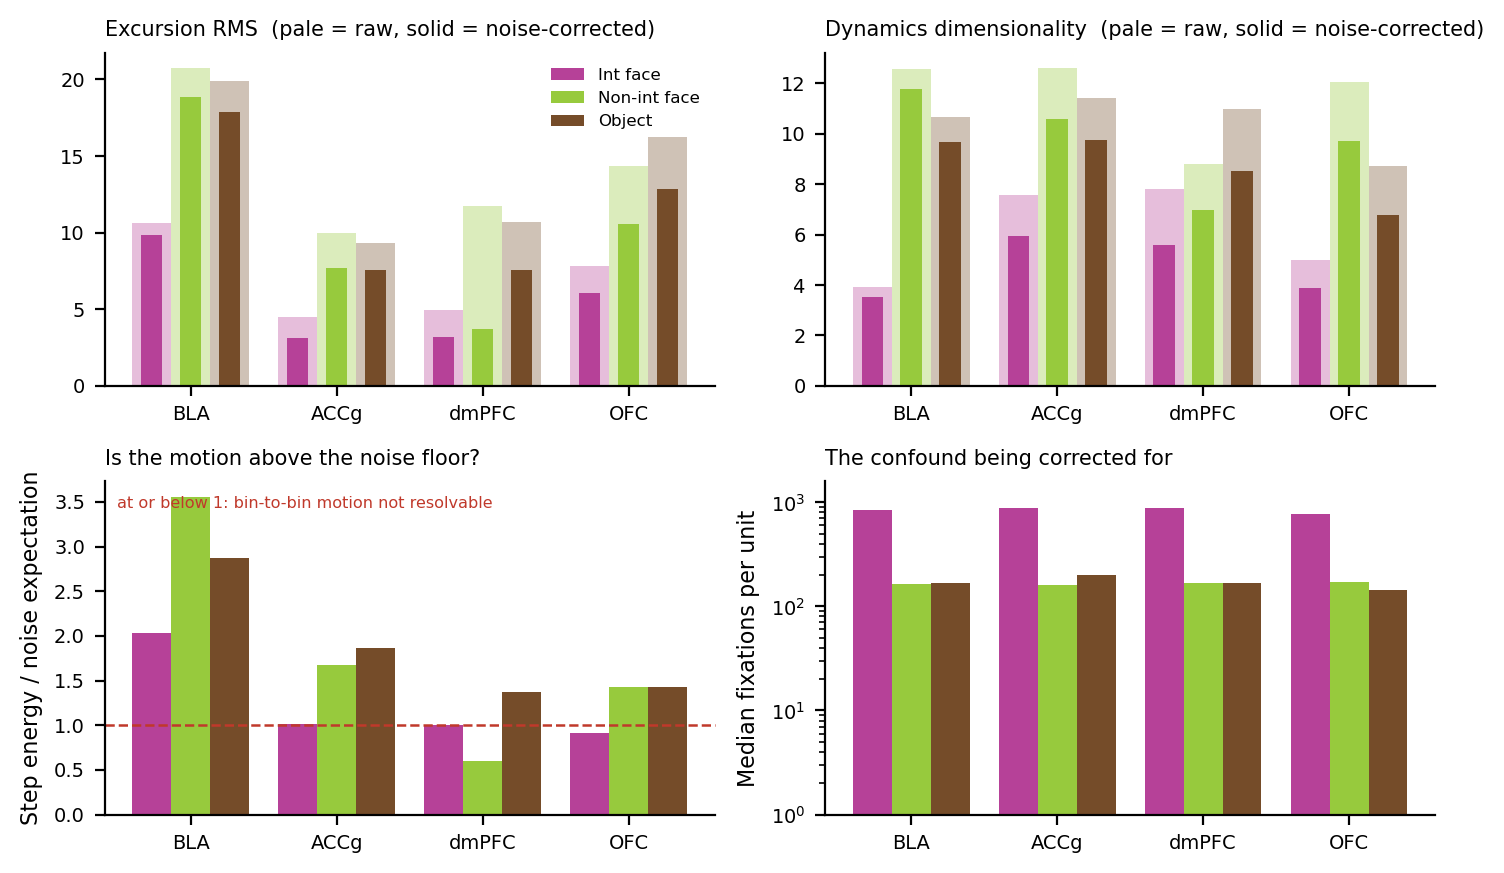

**Figure 11.** **How much each condition moves, before and after correcting for trial count.** *Top left*: excursion, the typical distance from a condition's own centroid. *Top right*: the effective number of dimensions that motion uses. Pale bars are raw, solid bars noise-corrected using the stored standard errors. *Bottom left*: measured step energy divided by the energy noise alone would produce — values near 1 mean moment-to-moment motion is not resolvable, which is why no speed is quoted. *Bottom right*: the trial-count imbalance being corrected for. Interactive face remains the most compact and lowest-dimensional condition after correction.

- Corrected excursion is smallest for interactive face in **4 of 4** regions.
- Its corrected dynamics dimensionality is the lowest in **4 of 4** regions.
- Moment-to-moment speed exceeds the noise floor in only 10 of 12 region x condition cases, so speed is not interpreted.

In [9]:
dynamics_summary = table(
    pd.concat(
        [
            pcs.condition_dynamics_summary(p, fits[r]["concatenated"], n_components=K)
            for r, p in populations.items()
        ],
        ignore_index=True,
    ),
    "t10_condition_dynamics",
)
figure(
    viz.plot_condition_dynamics(dynamics_summary),
    "fig11_condition_dynamics",
    "**How much each condition moves, before and after correcting for trial count.** *Top left*: "
    "excursion, the typical distance from a condition's own centroid. *Top right*: the effective "
    "number of dimensions that motion uses. Pale bars are raw, solid bars noise-corrected using the "
    "stored standard errors. *Bottom left*: measured step energy divided by the energy noise alone "
    "would produce — values near 1 mean moment-to-moment motion is not resolvable, which is why no "
    "speed is quoted. *Bottom right*: the trial-count imbalance being corrected for. "
    "Interactive face remains the most compact and lowest-dimensional condition after correction.",
)

compact = []
for region in sorted(populations):
    sub = dynamics_summary[dynamics_summary["region"] == region].set_index("condition")
    others = sub.drop("face_interactive")["excursion_rms_corrected"].min()
    compact.append(float(sub.loc["face_interactive", "excursion_rms_corrected"]) < others)
resolvable = int((dynamics_summary["speed_over_noise"] > 1.0).sum())
display(Markdown(
    f"- Corrected excursion is smallest for interactive face in **{sum(compact)} of {len(compact)}** regions.\n"
    f"- Its corrected dynamics dimensionality is the lowest in "
    f"**{sum(1 for r in sorted(populations) if dynamics_summary[dynamics_summary['region'] == r].set_index('condition')['dynamics_participation_ratio_corrected'].idxmin() == 'face_interactive')} "
    f"of {len(populations)}** regions.\n"
    f"- Moment-to-moment speed exceeds the noise floor in only {resolvable} of {len(dynamics_summary)} "
    "region x condition cases, so speed is not interpreted."
))

### 3.6 Ruling out the alternatives

Four things could produce the pattern above without any of it being a fact about
the populations. Each is checked.

**Could the separation be chance?** A condition-label shuffle permutes which of a
neuron's three traces is called which, independently per neuron. Every neuron
keeps all its real data; only the population's *agreement* about condition
identity is destroyed. Note this null points the opposite way to intuition: a
shuffled population has subspaces that are, if anything, *more* dissimilar, since
the real conditions share a large common fixation-locked response. What it tests
is whether the observed **shared** structure is real.

**Could it be a handful of neurons?** Resampling units with replacement and
refitting gives an interval on the separation at each time point. With
trial-averaged data there are no trials left to resample, so this asks the
question that matters for a population claim: would another sample of neurons from
this area show the same thing?

**Could it be one lucky split of the data?** Splitting the units into two disjoint
halves and rerunning the whole pipeline in each tests whether the geometry
replicates. The two halves span different neuron spaces so their axes are not
comparable, but the relative distances among the three conditions are.

**Could the timing of the separation be an artefact of the window?** The
time-resolved separation shows when the conditions diverge.

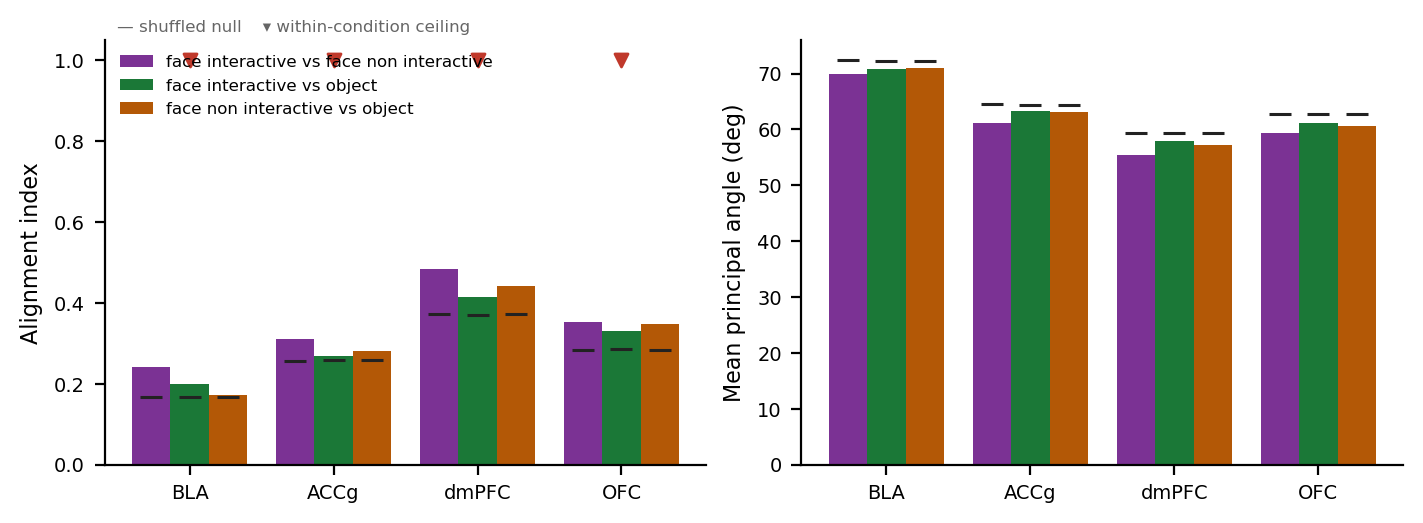

**Figure 12.** **Observed subspace similarity against a condition-label shuffle.** Bars are observed, dashes the shuffled null, triangles the within-condition ceiling. Observed subspaces are consistently *more* similar and *less* angularly separated than shuffled ones, confirming the shared structure across conditions is real rather than a by-product of how the data are arranged.

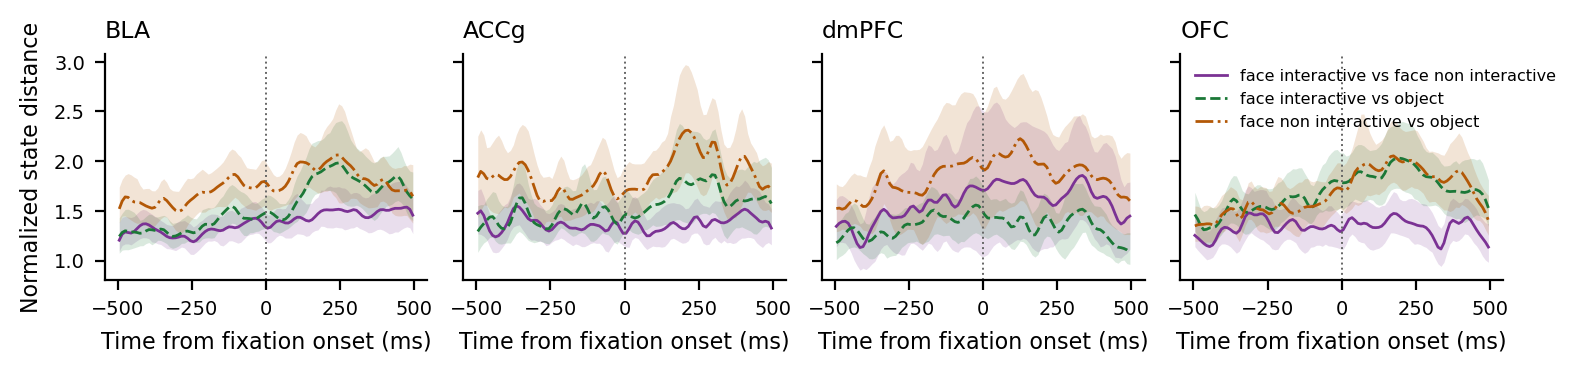

**Figure 13.** **When the conditions separate.** Distance between each pair of conditions through the fixation, normalised by trajectory scale; bands are 95% intervals from resampling neurons. Separation is already present before fixation onset — these are ongoing states, not evoked responses — and grows to a peak roughly 200-250 ms after onset. The two face conditions are the closest pair throughout in BLA, ACCg and OFC.

**Split-half reliability of the condition geometry**

,region,split_half_distance_correlation,pair_ordering_agreement,closest_pair_agreement,modal_closest_pair,modal_closest_pair_frequency
0,accg,0.874,0.90,0.90,face_interactive__vs__face_non_interactive,0.95
1,bla,0.829,0.92,0.92,face_interactive__vs__face_non_interactive,0.96
2,dmpfc,0.480,0.30,0.30,face_interactive__vs__object,0.65
3,ofc,0.827,0.10,1.00,face_interactive__vs__face_non_interactive,1.00


- **ACCg**: distances correlate across halves at r = 0.87; the two halves agree on which pair is closest on 90% of splits (chance 33%), and that pair is `IF/NF`.
- **BLA**: distances correlate across halves at r = 0.83; the two halves agree on which pair is closest on 92% of splits (chance 33%), and that pair is `IF/NF`.
- **dmPFC**: distances correlate across halves at r = 0.48; the two halves agree on which pair is closest on 30% of splits (chance 33%), and that pair is `IF/OB`.
- **OFC**: distances correlate across halves at r = 0.83; the two halves agree on which pair is closest on 100% of splits (chance 33%), and that pair is `IF/NF`.

Two rank statistics are reported because they disagree informatively. Requiring all three pairs to rank identically (chance 17%) is failed by OFC, but only because its two face-object distances are nearly tied and swap places; OFC agrees on the *closest* pair in 100% of splits. So the face-face pair is reliably the closest in BLA, ACCg and OFC, while dmPFC is again the exception — less reliable overall, and with a different closest pair.

In [10]:
null_comparison = table(
    pd.concat(
        [
            pcs.build_pairwise_null_comparison(
                p, n_components=K, n_shuffles=N_LABEL_SHUFFLES, seed=RANDOM_SEED
            )
            for p in populations.values()
        ],
        ignore_index=True,
    ),
    "t11_shuffle_null",
)
figure(
    viz.plot_null_comparison(null_comparison, ceiling=ceiling),
    "fig12_shuffle_null",
    "**Observed subspace similarity against a condition-label shuffle.** Bars are observed, dashes "
    "the shuffled null, triangles the within-condition ceiling. Observed subspaces are consistently "
    "*more* similar and *less* angularly separated than shuffled ones, confirming the shared "
    "structure across conditions is real rather than a by-product of how the data are arranged.",
)

separation = table(
    pd.concat(
        [
            pcs.time_resolved_separation(
                p, fits[r]["concatenated"], n_components=K,
                n_bootstrap=N_UNIT_BOOTSTRAPS, seed=RANDOM_SEED,
            )
            for r, p in populations.items()
        ],
        ignore_index=True,
    ),
    "t12_time_resolved_separation",
)
figure(
    viz.plot_time_resolved_separation(separation),
    "fig13_time_resolved_separation",
    "**When the conditions separate.** Distance between each pair of conditions through the "
    "fixation, normalised by trajectory scale; bands are 95% intervals from resampling neurons. "
    "Separation is already present before fixation onset — these are ongoing states, not evoked "
    "responses — and grows to a peak roughly 200-250 ms after onset. The two face conditions are "
    "the closest pair throughout in BLA, ACCg and OFC.",
)

reliability = table(
    pcs.summarize_split_half_reliability(
        pd.concat(
            [
                pcs.split_half_geometry_reliability(
                    p, n_components=K, n_splits=N_SPLIT_HALVES, seed=RANDOM_SEED
                )
                for p in populations.values()
            ],
            ignore_index=True,
        )
    ),
    "t13_split_half_reliability",
)
display(Markdown("**Split-half reliability of the condition geometry**"))
display(reliability[[
    "region", "split_half_distance_correlation", "pair_ordering_agreement",
    "closest_pair_agreement", "modal_closest_pair", "modal_closest_pair_frequency",
]].round(3))

lines = []
for _, row in reliability.iterrows():
    lines.append(
        f"- **{style.region_label(row['region'])}**: distances correlate across halves at "
        f"r = {row['split_half_distance_correlation']:.2f}; the two halves agree on which pair is "
        f"closest on {row['closest_pair_agreement']:.0%} of splits (chance 33%), and that pair is "
        f"`{PAIR_SHORT[row['modal_closest_pair']]}`."
    )
display(Markdown("\n".join(lines)))
display(Markdown(
    "Two rank statistics are reported because they disagree informatively. Requiring all three "
    "pairs to rank identically (chance 17%) is failed by OFC, but only because its two face-object "
    "distances are nearly tied and swap places; OFC agrees on the *closest* pair in 100% of splits. "
    "So the face-face pair is reliably the closest in BLA, ACCg and OFC, while dmPFC is again the "
    "exception — less reliable overall, and with a different closest pair."
))

---

## 4. Discussion

### 4.1 What the analysis establishes

**Three separable states, differing mainly in position.** In all four areas the
three fixation types place the population in clearly distinct states, separated
before fixation onset and most separated around 200–250 ms after it. But roughly
half of the population variance is a *constant* per-condition displacement, and
55–75% of the squared distance between any two conditions is positional. The
dominant representational difference is **where the population sits**, not what it
does over the following half second.

That is a substantive claim about coding format. A static offset is the signature
of a slowly-varying contextual or state variable — the population is in a "looking
at an interactive face" regime — rather than of a transient evoked response that
unfolds differently per stimulus.

**Faces and objects differ in their dynamics, and the difference is temporal
rather than dimensional.** This is the result we did not expect from the subspace
measures. Alignment and principal angles rank the two face conditions closest in
every region, but by margins small enough that one would hesitate to build on
them. Yet the two face conditions move through their neighbourhoods *in step*,
strongly and significantly, in BLA, ACCg and OFC — while face–object pairs are
indistinguishable from randomly time-shifted controls.

Face and object fixations therefore have comparable access to similar directions
of population activity, but only the two face conditions are driven along them by
a common, fixation-locked process. Figure 10 makes the dissociation directly
visible: the pairs do not order along the alignment axis at all, and separate
cleanly along the co-movement axis.

The natural reading is that a shared face-processing dynamic operates whether or
not the interaction is live, and that the interactive context shifts *where* that
dynamic runs — the offset — without changing its time course. Object fixations
engage a different process.

**The interactive-face state is compact.** Its excursion is roughly half that of
the other conditions and it uses fewer effective dimensions, in every region and
after correcting for the fivefold trial-count advantage that would otherwise
explain it. A tighter, lower-dimensional state is what one expects when the
population is strongly constrained — driven into a stereotyped configuration
rather than left free to vary.

**dmPFC is a different regime.** It has the highest floor-corrected alignment for
every pair, the largest share of variance in the offset term, and it is the only
area where face–object pairs also co-move. Its conditions share more structure
and are separated less categorically. Given dmPFC's smaller population (187 units)
this deserves care, but the floor correction is designed for exactly that and the
pattern is not simply a scaling of the others.

### 4.2 Why the co-movement measure was necessary

It is worth stating the methodological point plainly, because it generalises.

Subspace measures — alignment index, principal angles, cross-condition variance
explained — are all computed from **covariances**. A covariance summarises which
directions a signal varies along, and deliberately discards *when* it does so.
Two conditions with identical covariance structure can have completely unrelated
time courses, and every subspace measure will call them identical.

For condition-averaged data with a common temporal alignment — a fixation, a
saccade, a stimulus onset — the temporal correspondence is exactly the thing
worth testing, and it needs a measure that keeps time. The deviation correlation
is the simplest such measure, and the circular-shift null is what makes it
interpretable given that all the trajectories are smooth.

### 4.3 Limitations

**The object condition is not matched for interactive state.** Object fixations
are pooled across interactive and non-interactive periods, because there are too
few per state to average. So "object" differs from the two face conditions in
both what is fixated and in being a mixture over context. Some of the face–object
difference could be a context-mixing artefact rather than a category difference.
The interactive-state-matched variant of this analysis exists and is the place to
check this.

**No cross-validated effect sizes are available.** Cross-validated distances need
independent repeats of the same measurement, and trial averaging removed them.
Everything here rests on permutation nulls and resampling intervals. This is
adequate for the claims made but would not support, for example, an unbiased
estimate of representational distance.

**Nothing can be said about fine-timescale dynamics.** The 20 ms smoothing makes
the estimation noise autocorrelated at the timescale a 10 ms derivative probes,
and measured step energy is near the noise floor in most cases. Rotational
dynamics, speed differences and trajectory curvature are all out of reach with
these averages.

**Trajectories are averages, not single trials.** Everything here describes the
mean population response. A shared time course across two conditions in the
average is consistent with, but does not demonstrate, trial-by-trial coupling.

**Some of the geometry is less stable than the headline suggests.** Split-half
distance correlations are high in BLA, ACCg and OFC ($r = 0.83$–$0.87$) but only
moderate in dmPFC ($r = 0.48$), and dmPFC's closest pair is unstable across
halves. Distance *ordering* should therefore be read with care in that area. The
chapter's central claim does not rest on distance ordering — it rests on the
co-movement test, which has its own exact null — but the two should not be
conflated.

**Correlational.** These are observational recordings during natural gaze; the
conditions differ in many correlated ways (motivation, reward expectation, motor
plans) beyond the labels given to them.

### 4.4 What would settle the open questions

- **Single-trial trajectories** would allow a genuinely cross-validated distance
  and would test whether the face co-movement holds trial by trial or only in the
  average.
- **The interactive-state-matched conditions** (interactive object versus
  non-interactive object) would separate the context-mixing confound from the
  face–object difference.
- **Wider windows** would show whether the offsets are stable states or slow
  drifts on a timescale longer than the fixation.
- **Cross-region analyses** — whether the shared face dynamic is coordinated
  across areas — would say whether this reflects one distributed process or four
  local ones.

In [11]:
lines = ["### Numbers underlying the discussion\n"]
for region in sorted(populations):
    row = shares.loc[region]
    sub = pair_summary[pair_summary["region"] == region].set_index("pair")
    shift = shift_test[shift_test["region"] == region].set_index("pair_label")
    lines.append(
        f"- **{style.region_label(region)}** (n = {populations[region].n_units}): "
        f"variance = {row['condition_independent_time']:.0%} shared / "
        f"{row['condition_main_effect']:.0%} offset / {row['condition_by_time_interaction']:.0%} interaction; "
        f"alignment above floor IF/NF {sub.loc['IF/NF', 'alignment_above_floor']:.2f} vs "
        f"IF/OB {sub.loc['IF/OB', 'alignment_above_floor']:.2f}, NF/OB {sub.loc['NF/OB', 'alignment_above_floor']:.2f}; "
        "co-movement z = "
        + ", ".join(
            f"{PAIR_SHORT[label]} {shift.loc[label, 'z_against_shift_null']:+.1f}"
            + ("*" if shift.loc[label, "p_value"] < 0.05 else "")
            for label in PAIR_SHORT
        )
    )
display(Markdown("\n".join(lines)))
table(pd.DataFrame({"line": lines}), "t14_chapter_summary")

display(Markdown("---\n**Figures and tables written to:**"))
display(Markdown("\n".join(f"- `{name}`" for name in sorted(FIGURE_MANIFEST))))
print(FIGURE_DIR)

### Numbers underlying the discussion

- **ACCg** (n = 236): variance = 18% shared / 46% offset / 36% interaction; alignment above floor IF/NF 0.20 vs IF/OB 0.13, NF/OB 0.12; co-movement z = IF/NF +4.7*, IF/OB -0.3, NF/OB -1.7
- **BLA** (n = 537): variance = 21% shared / 45% offset / 33% interaction; alignment above floor IF/NF 0.20 vs IF/OB 0.15, NF/OB 0.11; co-movement z = IF/NF +10.1*, IF/OB +0.5, NF/OB +1.1
- **dmPFC** (n = 187): variance = 18% shared / 54% offset / 28% interaction; alignment above floor IF/NF 0.33 vs IF/OB 0.23, NF/OB 0.26; co-movement z = IF/NF +2.0, IF/OB +2.5*, NF/OB +1.7*
- **OFC** (n = 241): variance = 19% shared / 45% offset / 35% interaction; alignment above floor IF/NF 0.24 vs IF/OB 0.19, NF/OB 0.19; co-movement z = IF/NF +3.0*, IF/OB -0.1, NF/OB -0.2

---
**Figures and tables written to:**

- `fig01_decomposition_schematic.pdf`
- `fig01_decomposition_schematic.png`
- `fig02_dimensionality.pdf`
- `fig02_dimensionality.png`
- `fig03_trajectories_3d.pdf`
- `fig03_trajectories_3d.png`
- `fig04_pc_planes.pdf`
- `fig04_pc_planes.png`
- `fig05_pc_timecourses.pdf`
- `fig05_pc_timecourses.png`
- `fig06_offset_vs_dynamics.pdf`
- `fig06_offset_vs_dynamics.png`
- `fig07_cross_condition_variance.pdf`
- `fig07_cross_condition_variance.png`
- `fig08_comovement_schematic.pdf`
- `fig08_comovement_schematic.png`
- `fig09_offset_vs_dynamics_tested.pdf`
- `fig09_offset_vs_dynamics_tested.png`
- `fig10_alignment_vs_comovement.pdf`
- `fig10_alignment_vs_comovement.png`
- `fig11_condition_dynamics.pdf`
- `fig11_condition_dynamics.png`
- `fig12_shuffle_null.pdf`
- `fig12_shuffle_null.png`
- `fig13_time_resolved_separation.pdf`
- `fig13_time_resolved_separation.png`
- `t01_inventory.csv`
- `t02_dimensionality.csv`
- `t03_variance_decomposition.csv`
- `t04_offset_vs_dynamics.csv`
- `t05_subspace_metrics.csv`
- `t06_cross_condition_variance_curves.csv`
- `t07_alignment_ceiling.csv`
- `t08_pairwise_subspace_summary.csv`
- `t09_shift_test.csv`
- `t10_condition_dynamics.csv`
- `t11_shuffle_null.csv`
- `t12_time_resolved_separation.csv`
- `t13_split_half_reliability.csv`
- `t14_chapter_summary.csv`

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_population_pc_subspace/chapter
